In [1]:
# 0

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from itertools import combinations
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [2]:
# 1

XLSX = 'kospi_data.xlsx'
FIN_OUT = 'financials.parquet'

EXCLUDE_FIN = ['A000680', 'A000880', 'A005110', 'A008060', 'A015020', 'A023590',
               'A026890', 'A030190', 'A034310', 'A210980', 'A244920']

SHEET_ITEM = {
    '01_actq': 'actq', '02_rectq': 'rectq', '03_invtq': 'invtq',
    '04_ppentq': 'ppentq', '05_atq': 'atq', '06_lctq': 'lctq',
    '07_dlttq': 'dlttq', '08_dlcq': 'dlcq', '09_ltq': 'ltq',
    '10_seqq': 'seqq', '11_cogsq': 'cogsq', '12_xsgaq': 'xsgaq',
    '13_saleq': 'saleq', '14_apq': 'apq', '15_opinc': 'opinc',
    '16_xintq': 'xintq', '17_ibq': 'ibq', '18_txditcq': 'txditcq',
    '19_pstkq': 'pstkq', '20_cheq': 'cheq', '21_oancfq': 'oancfq',
    '22_dpq': 'dpq', '23_dvq': 'dvq', '24_cstkq': 'cstkq',
    '25_req': 'req', '26_epsq': 'epsq',
}

def load_sheet(path, sheet, var):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    periods = raw.iloc[9, 3:].tolist()
    body = raw.iloc[13:, :].reset_index(drop=True)
    codes = body.iloc[:, 0].astype(str)
    mask = codes.str.startswith('A')
    codes = codes[mask].reset_index(drop=True)
    vals = body.loc[mask.values, 3:].apply(pd.to_numeric, errors='coerce').reset_index(drop=True)
    vals.columns = periods
    vals.insert(0, 'code', codes)
    long = vals.melt(id_vars='code', var_name='period', value_name=var)
    long['date'] = pd.to_datetime(long['period'].astype(int).astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    return long[['code', 'date', var]]

def build_financials(path=XLSX, out=FIN_OUT):
    if Path(out).exists():
        fin = pd.read_parquet(out)
        fin = fin[~fin['code'].isin(EXCLUDE_FIN)].reset_index(drop=True)
        print(f'{out} loaded. shape {fin.shape}  n_comp {fin["code"].nunique()}')
        return fin
    fin = None
    for sheet, var in SHEET_ITEM.items():
        long = load_sheet(path, sheet, var)
        fin = long if fin is None else fin.merge(long, on=['code', 'date'], how='outer')
    fin = fin[~fin['code'].isin(EXCLUDE_FIN)]
    fin = fin.sort_values(['code', 'date']).reset_index(drop=True)
    fin.to_parquet(out)
    print(f'{out} written. shape {fin.shape}  n_comp {fin["code"].nunique()}  n_date {fin["date"].nunique()}')
    return fin

financials = build_financials()
print('columns:', financials.columns.tolist())

financials.parquet written. shape (116235, 28)  n_comp 1107  n_date 105
columns: ['code', 'date', 'actq', 'rectq', 'invtq', 'ppentq', 'atq', 'lctq', 'dlttq', 'dlcq', 'ltq', 'seqq', 'cogsq', 'xsgaq', 'saleq', 'apq', 'opinc', 'xintq', 'ibq', 'txditcq', 'pstkq', 'cheq', 'oancfq', 'dpq', 'dvq', 'cstkq', 'req', 'epsq']


In [3]:
# 2

FVOL_COLS = ['actq', 'rectq', 'invtq', 'ppentq', 'atq', 'lctq', 'dlcq',
             'apq', 'dlttq', 'ltq', 'seqq', 'xoprq', 'cogsq', 'xsgaq']

def compute_fvol(df, deflator='saleq', fvol_cols=FVOL_COLS, diff_lag=4, win=8, min_obs=4):
    d = df.sort_values(['code', 'date']).reset_index(drop=True).copy()
    d['xoprq'] = d['cogsq'] + d['xsgaq']

    pq = pd.PeriodIndex(d['date'], freq='Q')
    d['qidx'] = pq.year * 4 + (pq.quarter - 1)

    g = d.groupby('code', sort=False)
    has_lag = (d['qidx'] - g['qidx'].shift(diff_lag)) == diff_lag
    for c in fvol_cols:
        d[f'd_{c}'] = np.where(has_lag, d[c] - g[c].shift(diff_lag), np.nan)

    g = d.groupby('code', sort=False)
    for c in fvol_cols:
        d[f'std_{c}'] = (g[f'd_{c}'].apply(lambda s: s.rolling(win, min_periods=min_obs).std())
                         .reset_index(level=0, drop=True))

    d['defl_pos'] = d[deflator].where(d[deflator] > 0)
    g = d.groupby('code', sort=False)
    d['avg_defl'] = (g['defl_pos'].apply(lambda s: s.rolling(win, min_periods=min_obs).mean())
                     .reset_index(level=0, drop=True))
    d['avg_defl'] = d['avg_defl'].where(d['avg_defl'] > 0)

    ind = []
    for c in fvol_cols:
        d[f'fvol_{c}'] = d[f'std_{c}'] / d['avg_defl']
        ind.append(f'fvol_{c}')
    return d, ind

def finalize_fvol(d, ind, fvol_cols=FVOL_COLS, min_valid=10, suffix=''):
    d = d.copy()
    rcols = [f'rank_{c}' for c in fvol_cols]
    ranked = d.groupby('date')[ind].rank(pct=True)
    ranked.columns = rcols
    d = pd.concat([d, ranked], axis=1)
    d['n_valid'] = d[rcols].notna().sum(axis=1)
    col = f'FVOL{suffix}'
    d[col] = d[rcols].mean(axis=1)
    d.loc[d['n_valid'] < min_valid, col] = np.nan
    return d, col

financials = pd.read_parquet('financials.parquet')

fv_sale, ind = compute_fvol(financials, deflator='saleq')
fv_sale, col_s = finalize_fvol(fv_sale, ind, suffix='_sale')

fv_asset, ind = compute_fvol(financials, deflator='atq')
fv_asset, col_a = finalize_fvol(fv_asset, ind, suffix='_asset')

fvol = fv_sale[['code', 'date', col_s]].merge(
    fv_asset[['code', 'date', col_a]], on=['code', 'date'])

for c in [col_s, col_a]:
    v = fvol[fvol[c].notna()]
    print(f'{c}: valid {len(v)}  avg firms/q {v.groupby("date").size().mean():.0f}  '
          f'range {v["date"].min().date()}~{v["date"].max().date()}')
    print(f'  describe: {v[c].describe()[["mean","std","min","50%","max"]].round(3).to_dict()}')

corr = fvol[[col_s, col_a]].corr().iloc[0, 1]
print(f'\n매출분모 FVOL vs 자산분모 FVOL 상관: {corr:.3f}')
print('\n분기당 종목수 (매출분모):')
gq = fvol[fvol[col_s].notna()].groupby('date').size()
print(gq.iloc[[0, len(gq)//4, len(gq)//2, 3*len(gq)//4, -1]].to_string())

FVOL_sale: valid 66765  avg firms/q 681  range 2001-12-31~2026-03-31
  describe: {'mean': 0.501, 'std': 0.203, 'min': 0.021, '50%': 0.483, 'max': 1.0}
FVOL_asset: valid 66828  avg firms/q 682  range 2001-12-31~2026-03-31
  describe: {'mean': 0.501, 'std': 0.189, 'min': 0.022, '50%': 0.49, 'max': 1.0}

매출분모 FVOL vs 자산분모 FVOL 상관: 0.713

분기당 종목수 (매출분모):
date
2001-12-31    557
2007-12-31    639
2014-03-31    675
2020-03-31    729
2026-03-31    763


In [4]:
# 3

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

rcols = [f'rank_{c}' for c in FVOL_COLS]
valid = fv[fv['FVOL'].notna()].copy()

print('=== Panel A: 14개 개별 측정치 분포 (fvol_k 원값) ===')
print(f'{"item":8s}{"mean":>10s}{"std":>10s}{"median":>10s}{"N":>8s}')
for c in FVOL_COLS:
    s = fv[f'fvol_{c}'].replace([np.inf,-np.inf], np.nan).dropna()
    print(f'{c:8s}{s.mean():>10.3f}{s.std():>10.3f}{s.median():>10.3f}{len(s):>8d}')

print('\n=== Panel B: 각 측정치 rank와 FVOL의 상관 (공통성분) ===')
print('개별 fvol_k rank가 종합 FVOL과 얼마나 상관되는지:')
for c in FVOL_COLS:
    corr = valid[[f'rank_{c}', 'FVOL']].corr().iloc[0,1]
    print(f'  {c:8s}: {corr:.3f}')

print('\n=== 14개 측정치 rank 간 평균 Spearman 상관 ===')
rank_corr = valid[rcols].corr()
mask = ~np.eye(14, dtype=bool)
print(f'  평균 pairwise 상관: {rank_corr.values[mask].mean():.3f}')
print(f'  최소: {rank_corr.values[mask].min():.3f}  최대: {rank_corr.values[mask].max():.3f}')

print('\n=== 상관행렬 (rank 간) ===')
short = [c.replace('q','') for c in FVOL_COLS]
rc = rank_corr.copy()
rc.index = short; rc.columns = short
print(rc.round(2).to_string())

=== Panel A: 14개 개별 측정치 분포 (fvol_k 원값) ===
item          mean       std    median       N
actq         0.566     1.920     0.248   66792
rectq        0.226     0.716     0.114   66780
invtq        0.137     0.315     0.079   64601
ppentq       0.338     3.206     0.098   66764
atq          0.834     3.972     0.313   66792
lctq         0.640     6.468     0.259   66792
dlcq         0.340     1.339     0.162   66792
apq          0.259     5.893     0.110   66760
dlttq        0.220     0.788     0.089   44357
ltq          0.825    19.774     0.255   66792
seqq         0.710    20.274     0.144   66792
xoprq        0.266     1.666     0.127   66196
cogsq        0.235     1.478     0.118   66630
xsgaq        0.069     0.578     0.019   66196

=== Panel B: 각 측정치 rank와 FVOL의 상관 (공통성분) ===
개별 fvol_k rank가 종합 FVOL과 얼마나 상관되는지:
  actq    : 0.823
  rectq   : 0.708
  invtq   : 0.576
  ppentq  : 0.561
  atq     : 0.852
  lctq    : 0.820
  dlcq    : 0.632
  apq     : 0.706
  dlttq   : 0.485
  ltq   

In [5]:
# 4

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

d = fv[['code', 'date', 'FVOL']].dropna().copy()
d['qidx'] = pd.PeriodIndex(d['date'], freq='Q').year * 4 + (pd.PeriodIndex(d['date'], freq='Q').quarter - 1)
d = d.sort_values(['code', 'qidx']).reset_index(drop=True)

print('=== FVOL 자기상관 (lag별) ===')
print('같은 종목의 FVOL(t)와 FVOL(t+k) 상관:')
for lag in [1, 2, 4, 8, 12, 20]:
    g = d.copy()
    g['fut_qidx'] = g['qidx'] + lag
    merged = g.merge(g[['code','qidx','FVOL']].rename(columns={'qidx':'fut_qidx','FVOL':'FVOL_fut'}),
                     on=['code','fut_qidx'], how='inner')
    corr = merged[['FVOL','FVOL_fut']].corr().iloc[0,1]
    print(f'  lag {lag:2d}분기 ({lag/4:.1f}년): 상관 {corr:.3f}  (n={len(merged)})')

print('\n=== 분위 유지율 (transition) ===')
print('이번 분기 decile이 k분기 후에도 같은/인접 decile에 남는 비율:')
d['dec'] = d.groupby('date')['FVOL'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
for lag in [1, 4, 8]:
    g = d.copy()
    g['fut_qidx'] = g['qidx'] + lag
    m = g.merge(g[['code','qidx','dec']].rename(columns={'qidx':'fut_qidx','dec':'dec_fut'}),
                on=['code','fut_qidx'], how='inner')
    same = (m['dec'] == m['dec_fut']).mean()
    adj = (abs(m['dec'] - m['dec_fut']) <= 1).mean()
    print(f'  lag {lag}분기: 동일 decile {same:.1%}, ±1 이내 {adj:.1%}')

print('\n=== 극단 분위의 지속성 (전이 확률) ===')
print('최저(0)·최고(9) decile이 4분기 후 어디로 가는지:')
g = d.copy(); g['fut_qidx'] = g['qidx'] + 4
m = g.merge(g[['code','qidx','dec']].rename(columns={'qidx':'fut_qidx','dec':'dec_fut'}),
            on=['code','fut_qidx'], how='inner')
for start in [0, 9]:
    sub = m[m['dec'] == start]['dec_fut']
    print(f'  decile {start}: 4분기 후 평균 decile {sub.mean():.2f}, 같은 곳 유지 {(sub==start).mean():.1%}')

=== FVOL 자기상관 (lag별) ===
같은 종목의 FVOL(t)와 FVOL(t+k) 상관:
  lag  1분기 (0.2년): 상관 0.973  (n=65802)
  lag  2분기 (0.5년): 상관 0.933  (n=64842)
  lag  4분기 (1.0년): 상관 0.843  (n=62929)
  lag  8분기 (2.0년): 상관 0.667  (n=59209)
  lag 12분기 (3.0년): 상관 0.547  (n=55584)
  lag 20분기 (5.0년): 상관 0.457  (n=48687)

=== 분위 유지율 (transition) ===
이번 분기 decile이 k분기 후에도 같은/인접 decile에 남는 비율:
  lag 1분기: 동일 decile 64.4%, ±1 이내 95.5%
  lag 4분기: 동일 decile 35.0%, ±1 이내 71.7%
  lag 8분기: 동일 decile 23.9%, ±1 이내 55.4%

=== 극단 분위의 지속성 (전이 확률) ===
최저(0)·최고(9) decile이 4분기 후 어디로 가는지:
  decile 0: 4분기 후 평균 decile 0.81, 같은 곳 유지 59.1%
  decile 9: 4분기 후 평균 decile 8.49, 같은 곳 유지 70.1%


In [6]:
# 5

ALL_ITEMS = ['actq','rectq','invtq','ppentq','atq','lctq','dlttq','dlcq','ltq',
             'seqq','cogsq','xsgaq','saleq','apq','opinc','xintq','ibq','txditcq',
             'pstkq','cheq','oancfq','dpq','dvq','cstkq','req','epsq']

print('=== 1. 항목별 결측률 (FVOL 14개 표시) ===')
FVOL14 = ['actq','rectq','invtq','ppentq','atq','lctq','dlcq','apq','dlttq','ltq','seqq','cogsq','xsgaq']
for c in ALL_ITEMS:
    nan = financials[c].isna().mean()
    tag = ' [FVOL]' if c in FVOL14 else ''
    print(f'  {c:9s}: {nan:.1%}{tag}')

print('\n=== 2. 폐지 종목 실태 ===')
last_date = financials.groupby('code')['atq'].apply(lambda s: financials.loc[s.index, 'date'][s.notna()].max())
last_date = financials[financials['atq'].notna()].groupby('code')['date'].max()
cutoff = financials['date'].max()
print(f'데이터 최종 시점: {cutoff.date()}')
delisted = last_date[last_date < cutoff - pd.Timedelta(days=200)]
print(f'마지막 데이터가 최근이 아닌 종목(폐지 추정): {len(delisted)} / {financials["code"].nunique()}')
print('폐지 시점 분포 (연도별):')
print(delisted.dt.year.value_counts().sort_index().to_string())

print('\n=== 3. 종목별 데이터 이력 길이 ===')
life = financials[financials['atq'].notna()].groupby('code')['date'].agg(['min','max','count'])
print('데이터 존재 분기 수 분포:')
print(life['count'].describe()[['min','25%','50%','75%','max']].round(0).to_string())
print(f'  8분기 미만(측정 워밍업 부족) 종목: {(life["count"]<8).sum()}')

print('\n=== 4. 차분 이상치 점검 (A6: 구조적 단절) ===')
d = financials.sort_values(['code','date']).copy()
d['atq_chg'] = d.groupby('code')['atq'].pct_change(4)
extreme = d['atq_chg'].abs() > 2
print(f'자산총계 4분기 변화율 |>200%| 관측치: {extreme.sum()} ({extreme.mean():.2%})')
print(f'  변화율 분포: {d["atq_chg"].describe()[["min","25%","50%","75%","max"]].round(2).to_dict()}')

=== 1. 항목별 결측률 (FVOL 14개 표시) ===
  actq     : 36.2% [FVOL]
  rectq    : 36.2% [FVOL]
  invtq    : 38.2% [FVOL]
  ppentq   : 36.2% [FVOL]
  atq      : 36.2% [FVOL]
  lctq     : 36.2% [FVOL]
  dlttq    : 54.9% [FVOL]
  dlcq     : 36.2% [FVOL]
  ltq      : 36.2% [FVOL]
  seqq     : 36.2% [FVOL]
  cogsq    : 36.8% [FVOL]
  xsgaq    : 37.8% [FVOL]
  saleq    : 37.9%
  apq      : 36.2% [FVOL]
  opinc    : 37.8%
  xintq    : 43.3%
  ibq      : 37.8%
  txditcq  : 62.5%
  pstkq    : 88.9%
  cheq     : 36.2%
  oancfq   : 44.5%
  dpq      : 46.0%
  dvq      : 35.9%
  cstkq    : 36.3%
  req      : 36.3%
  epsq     : 37.8%

=== 2. 폐지 종목 실태 ===
데이터 최종 시점: 2026-03-31
마지막 데이터가 최근이 아닌 종목(폐지 추정): 222 / 1107
폐지 시점 분포 (연도별):
date
2000    15
2001    22
2002     8
2003    16
2004    18
2005     4
2006    10
2007     4
2008    13
2009    18
2010    11
2011     3
2012    15
2013     5
2014     6
2015     7
2016     8
2017     4
2018     3
2019     4
2020     6
2021     6
2022     1
2023     4
2024     4
2025 

In [7]:
# 6

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

d = fv.sort_values(['code','date']).copy()

g = d.groupby('code', sort=False)
d['atq_lag1'] = g['atq'].shift(1)
d['qbe'] = d['seqq'].fillna(0) + d['txditcq'].fillna(0) - d['pstkq'].fillna(0)
d['qbe_lag1'] = g['qbe'].shift(1)

d['GP'] = (d['saleq'] - d['cogsq']) / d['atq_lag1']
d['OP'] = (d['saleq'] - d['cogsq'] - d['xsgaq'] - d['xintq']) / d['qbe_lag1']
d['ROE'] = d['ibq'] / d['qbe_lag1']

for c in ['GP','OP','ROE']:
    d[c] = d[c].replace([np.inf,-np.inf], np.nan)

v = d[d['FVOL'].notna()].copy()
v['dec'] = v.groupby('date')['FVOL'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')) + 1

print('=== FVOL decile별 수익성 (분기별 중앙값의 평균) ===')
print('decile 1=최저FVOL(롱), 10=최고FVOL(숏)\n')
print(f'{"decile":>7s}{"GP":>10s}{"OP":>10s}{"ROE":>10s}{"n":>8s}')
tbl = {}
for c in ['GP','OP','ROE']:
    med = v.groupby(['date','dec'])[c].median().reset_index()
    tbl[c] = med.groupby('dec')[c].mean()
cnt = v.groupby('dec').size()
for dc in range(1, 11):
    print(f'{dc:>7d}{tbl["GP"][dc]:>10.3f}{tbl["OP"][dc]:>10.3f}{tbl["ROE"][dc]:>10.3f}{cnt[dc]:>8d}')

print('\n=== 단조성 검정 (Low decile 1 vs High decile 10) ===')
for c in ['GP','OP','ROE']:
    lo, hi = tbl[c][1], tbl[c][10]
    monotone = all(tbl[c][i] >= tbl[c][i+1] for i in range(1, 10))
    n_desc = sum(tbl[c][i] >= tbl[c][i+1] for i in range(1, 10))
    print(f'  {c}: 저FVOL {lo:.3f} → 고FVOL {hi:.3f} (차이 {lo-hi:+.3f}), '
          f'완전단조 {monotone}, 감소구간 {n_desc}/9')

print('\n=== 자산분모 FVOL로도 동일 확인 ===')
fv2, ind2 = compute_fvol(financials, deflator='atq')
fv2, _ = finalize_fvol(fv2, ind2, suffix='')
d2 = d.merge(fv2[['code','date','FVOL']].rename(columns={'FVOL':'FVOL_a'}), on=['code','date'])
v2 = d2[d2['FVOL_a'].notna()].copy()
v2['dec'] = v2.groupby('date')['FVOL_a'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')) + 1
for c in ['GP','OP','ROE']:
    m = v2.groupby(['date','dec'])[c].median().reset_index().groupby('dec')[c].mean()
    print(f'  {c}(자산분모): 저 {m[1]:.3f} → 고 {m[10]:.3f} (차이 {m[1]-m[10]:+.3f})')

=== FVOL decile별 수익성 (분기별 중앙값의 평균) ===
decile 1=최저FVOL(롱), 10=최고FVOL(숏)

 decile        GP        OP       ROE       n
      1     0.054     0.023     0.022    6716
      2     0.046     0.020     0.019    6673
      3     0.043     0.018     0.018    6665
      4     0.039     0.016     0.016    6669
      5     0.037     0.014     0.014    6682
      6     0.035     0.012     0.013    6653
      7     0.033     0.010     0.011    6661
      8     0.030     0.006     0.008    6673
      9     0.026     0.001     0.004    6665
     10     0.017    -0.015    -0.015    6708

=== 단조성 검정 (Low decile 1 vs High decile 10) ===
  GP: 저FVOL 0.054 → 고FVOL 0.017 (차이 +0.037), 완전단조 True, 감소구간 9/9
  OP: 저FVOL 0.023 → 고FVOL -0.015 (차이 +0.038), 완전단조 True, 감소구간 9/9
  ROE: 저FVOL 0.022 → 고FVOL -0.015 (차이 +0.037), 완전단조 True, 감소구간 9/9

=== 자산분모 FVOL로도 동일 확인 ===
  GP(자산분모): 저 0.034 → 고 0.029 (차이 +0.005)
  OP(자산분모): 저 0.014 → 고 -0.001 (차이 +0.015)
  ROE(자산분모): 저 0.016 → 고 -0.001 (차이 +0.017)


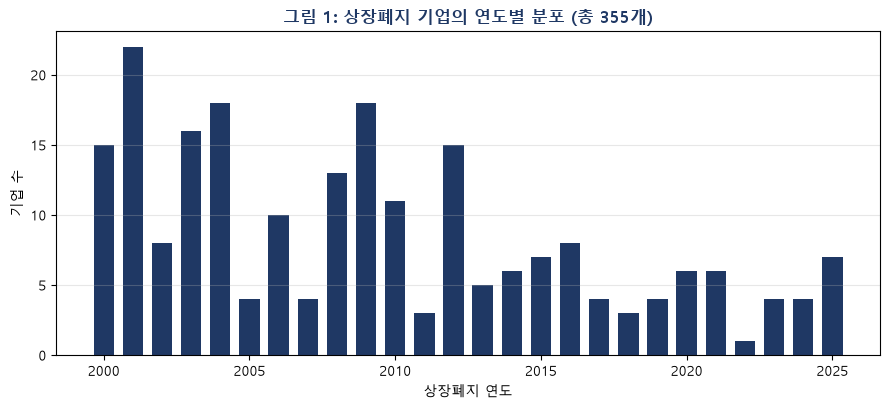

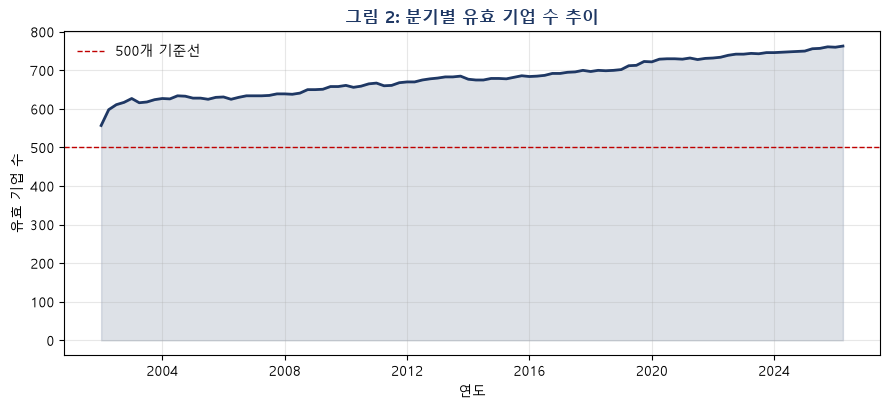

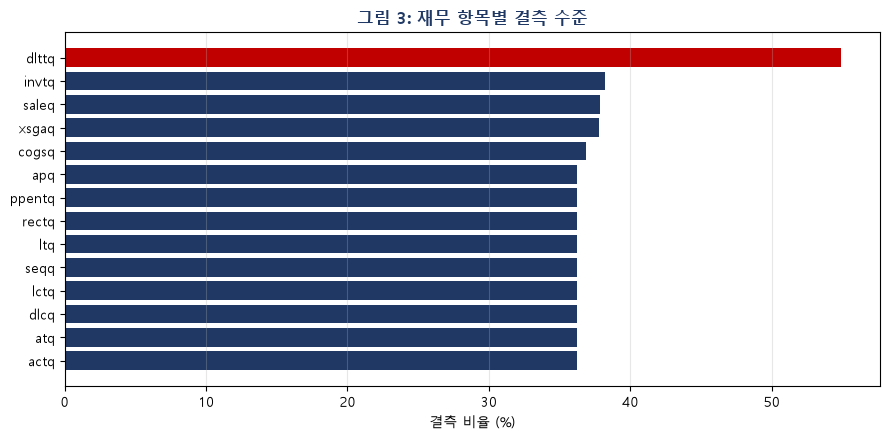

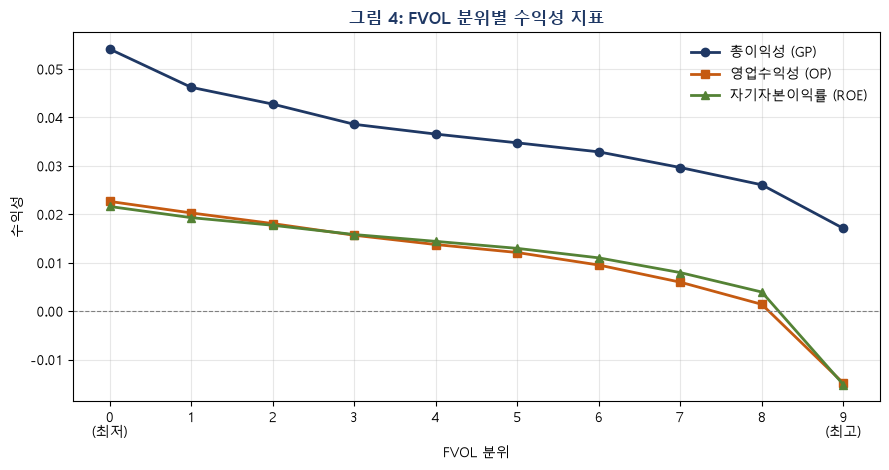

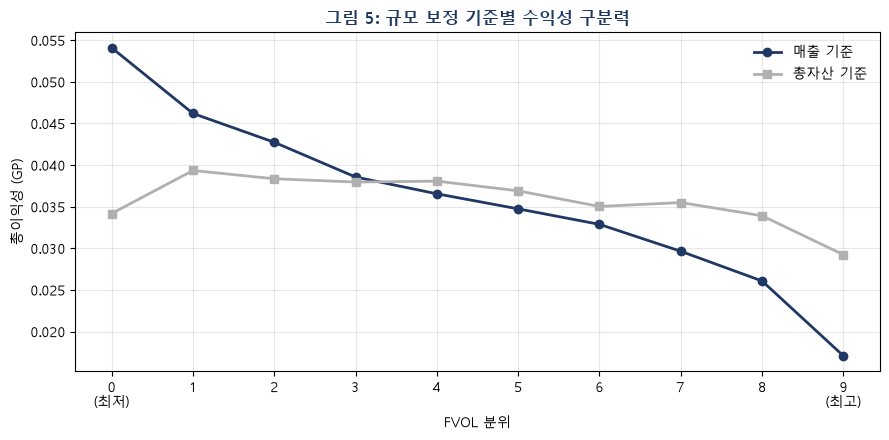

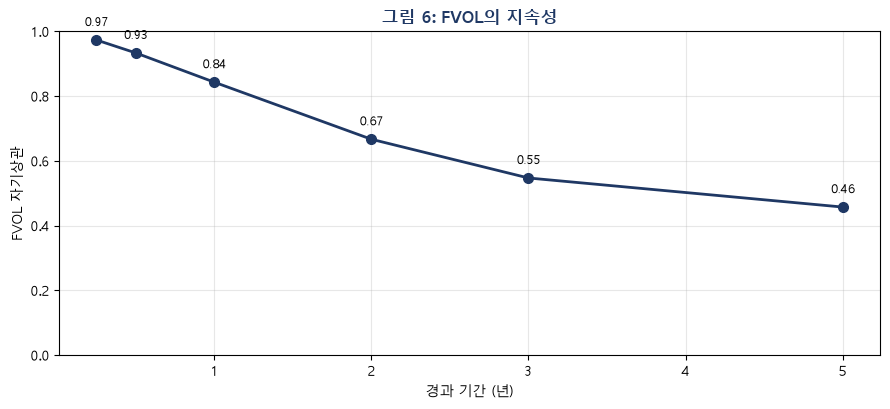

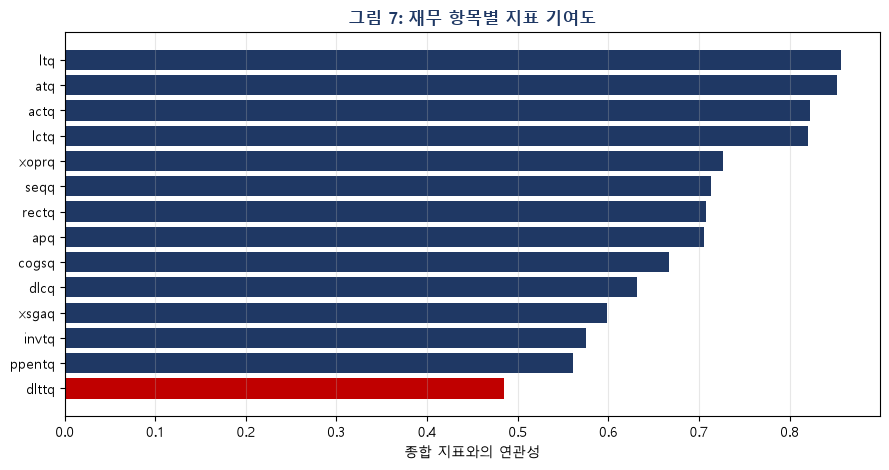

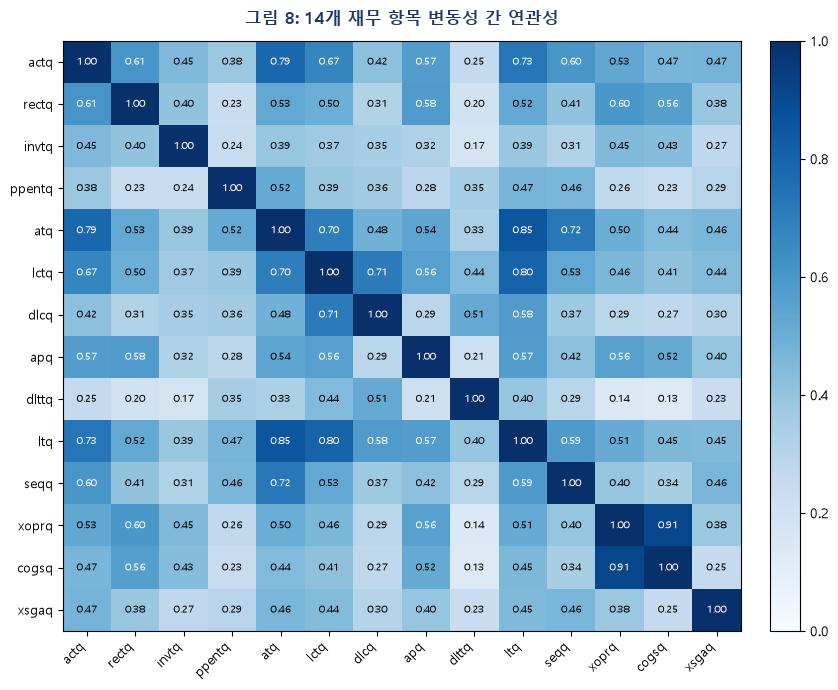

In [24]:
# 시각화

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
NAVY = '#1F3864'

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

d = fv.sort_values(['code','date']).copy()
g = d.groupby('code', sort=False)
d['atq_lag1'] = g['atq'].shift(1)
d['qbe'] = d['seqq'].fillna(0) + d['txditcq'].fillna(0) - d['pstkq'].fillna(0)
d['qbe_lag1'] = g['qbe'].shift(1)
d['GP'] = (d['saleq'] - d['cogsq']) / d['atq_lag1']
d['OP'] = (d['saleq'] - d['cogsq'] - d['xsgaq'] - d['xintq']) / d['qbe_lag1']
d['ROE'] = d['ibq'] / d['qbe_lag1']
for c in ['GP','OP','ROE']:
    d[c] = d[c].replace([np.inf,-np.inf], np.nan)

last_date = financials[financials['atq'].notna()].groupby('code')['date'].max()
cutoff = financials['date'].max()
delisted = last_date[last_date < cutoff - pd.Timedelta(days=200)]
dist = delisted.dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(dist.index, dist.values, color=NAVY, width=0.7)
ax.set_xlabel('상장폐지 연도'); ax.set_ylabel('기업 수')
ax.set_title('그림 1: 상장폐지 기업의 연도별 분포 (총 355개)', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

gq = fv[fv['FVOL'].notna()].groupby('date').size()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(gq.index, gq.values, color=NAVY, linewidth=2)
ax.fill_between(gq.index, gq.values, alpha=0.15, color=NAVY)
ax.axhline(500, color='#C00000', linestyle='--', linewidth=1, label='500개 기준선')
ax.set_xlabel('연도'); ax.set_ylabel('유효 기업 수')
ax.set_title('그림 2: 분기별 유효 기업 수 추이', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

ALL_ITEMS = ['actq','rectq','invtq','ppentq','atq','lctq','dlttq','dlcq','ltq',
             'seqq','cogsq','xsgaq','saleq','apq']
miss = {c: financials[c].isna().mean()*100 for c in ALL_ITEMS}
miss = pd.Series(miss).sort_values()
colors = ['#C00000' if c=='dlttq' else NAVY for c in miss.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(range(len(miss)), miss.values, color=colors)
ax.set_yticks(range(len(miss))); ax.set_yticklabels(miss.index)
ax.set_xlabel('결측 비율 (%)')
ax.set_title('그림 3: 재무 항목별 결측 수준', fontweight='bold', color=NAVY)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

v = d[d['FVOL'].notna()].copy()
v['dec'] = v.groupby('date')['FVOL'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
series = {c: v.groupby(['date','dec'])[c].median().reset_index().groupby('dec')[c].mean() for c in ['GP','OP','ROE']}
fig, ax = plt.subplots(figsize=(9, 4.8))
labels = {'GP':'총이익성 (GP)', 'OP':'영업수익성 (OP)', 'ROE':'자기자본이익률 (ROE)'}
colors = {'GP':NAVY, 'OP':'#C55A11', 'ROE':'#548235'}
markers = {'GP':'o', 'OP':'s', 'ROE':'^'}
for c in ['GP','OP','ROE']:
    ax.plot(range(10), series[c].values, marker=markers[c], color=colors[c], label=labels[c], linewidth=2, markersize=6)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xticks(range(10)); ax.set_xticklabels(['0\n(최저)','1','2','3','4','5','6','7','8','9\n(최고)'])
ax.set_xlabel('FVOL 분위'); ax.set_ylabel('수익성')
ax.set_title('그림 4: FVOL 분위별 수익성 지표', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fv2, ind2 = compute_fvol(financials, deflator='atq')
fv2, _ = finalize_fvol(fv2, ind2, suffix='')
d2 = d.merge(fv2[['code','date','FVOL']].rename(columns={'FVOL':'FVOL_a'}), on=['code','date'])
v2 = d2[d2['FVOL_a'].notna()].copy()
v2['dec'] = v2.groupby('date')['FVOL_a'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
gp_sale = series['GP']
gp_asset = v2.groupby(['date','dec'])['GP'].median().reset_index().groupby('dec')['GP'].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(10), gp_sale.values, marker='o', color=NAVY, linewidth=2, label='매출 기준')
ax.plot(range(10), gp_asset.values, marker='s', color='#B0B0B0', linewidth=2, label='총자산 기준')
ax.set_xticks(range(10)); ax.set_xticklabels(['0\n(최저)','1','2','3','4','5','6','7','8','9\n(최고)'])
ax.set_xlabel('FVOL 분위'); ax.set_ylabel('총이익성 (GP)')
ax.set_title('그림 5: 규모 보정 기준별 수익성 구분력', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

dd = fv[['code','date','FVOL']].dropna().copy()
pq = pd.PeriodIndex(dd['date'], freq='Q')
dd['qidx'] = pq.year * 4 + (pq.quarter - 1)
lags = [1,2,4,8,12,20]; corrs = []
for lag in lags:
    a = dd.copy(); a['fut'] = a['qidx'] + lag
    m = a.merge(a[['code','qidx','FVOL']].rename(columns={'qidx':'fut','FVOL':'FVOL_f'}), on=['code','fut'], how='inner')
    corrs.append(m[['FVOL','FVOL_f']].corr().iloc[0,1])
fig, ax = plt.subplots(figsize=(9, 4.2))
years = [l/4 for l in lags]
ax.plot(years, corrs, marker='o', color=NAVY, linewidth=2, markersize=7)
for x,y in zip(years, corrs):
    ax.annotate(f'{y:.2f}', (x,y), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
ax.set_xlabel('경과 기간 (년)'); ax.set_ylabel('FVOL 자기상관'); ax.set_ylim(0, 1)
ax.set_title('그림 6: FVOL의 지속성', fontweight='bold', color=NAVY)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

rcols = [f'rank_{c}' for c in FVOL_COLS]
valid = fv[fv['FVOL'].notna()]
contrib = {c: valid[[f'rank_{c}','FVOL']].corr().iloc[0,1] for c in FVOL_COLS}
contrib = pd.Series(contrib).sort_values()
colors = ['#C00000' if c=='dlttq' else NAVY for c in contrib.index]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(range(len(contrib)), contrib.values, color=colors)
ax.set_yticks(range(len(contrib))); ax.set_yticklabels(contrib.index)
ax.set_xlabel('종합 지표와의 연관성')
ax.set_title('그림 7: 재무 항목별 지표 기여도', fontweight='bold', color=NAVY)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

rank_corr = valid[rcols].corr()
labels = list(FVOL_COLS)
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(rank_corr.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(14)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(14)); ax.set_yticklabels(labels, fontsize=9)
for i in range(14):
    for j in range(14):
        val = rank_corr.values[i,j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white' if val > 0.55 else 'black', fontsize=7)
ax.set_title('그림 8: 14개 재무 항목 변동성 간 연관성', fontweight='bold', color=NAVY, pad=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

In [9]:
# 7

PRICE_OUT = 'prices.parquet'
MARKET_OUT = 'market.parquet'

PRICE_SHEETS = {
    '27_return': 'ret',
    '28_mktcap': 'mktcap',
    '29_price': 'price',
    '30_dret': 'dret',
}

MARKET_SHEETS = {
    '31_kret': 'kret',
    '32_rf': 'rf',
}

def load_wide_sheet(path, sheet, var):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    codes = raw.iloc[7, 1:].astype(str)
    mask = codes.str.startswith('A')
    codes = codes[mask]
    dates = pd.to_datetime(raw.iloc[14:, 0].tolist())
    vals = raw.iloc[14:, 1:].loc[:, mask.values].apply(pd.to_numeric, errors='coerce')
    vals.columns = codes.values
    vals.index = dates
    long = vals.stack().rename(var).reset_index()
    long.columns = ['date', 'code', var]
    return long[['code', 'date', var]]

def load_single_sheet(path, sheet, var):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    dates = pd.to_datetime(raw.iloc[14:, 0].tolist())
    vals = pd.to_numeric(raw.iloc[14:, 1], errors='coerce')
    return pd.DataFrame({'date': dates, var: vals.values})

def build_prices(path=XLSX, out=PRICE_OUT):
    if Path(out).exists():
        df = pd.read_parquet(out)
        df = df[~df['code'].isin(EXCLUDE_FIN)].reset_index(drop=True)
        print(f'{out} loaded. shape {df.shape}  n_comp {df["code"].nunique()}')
        return df
    monthly = None
    for sheet, var in [('27_return', 'ret'), ('28_mktcap', 'mktcap'), ('29_price', 'price')]:
        long = load_wide_sheet(path, sheet, var)
        monthly = long if monthly is None else monthly.merge(long, on=['code', 'date'], how='outer')
    monthly = monthly[~monthly['code'].isin(EXCLUDE_FIN)]
    monthly = monthly.sort_values(['code', 'date']).reset_index(drop=True)
    monthly.to_parquet(out)
    print(f'{out} written. shape {monthly.shape}  n_comp {monthly["code"].nunique()}  n_date {monthly["date"].nunique()}')
    return monthly

def build_daily(path=XLSX, out='daily_returns.parquet'):
    if Path(out).exists():
        df = pd.read_parquet(out)
        df = df[~df['code'].isin(EXCLUDE_FIN)].reset_index(drop=True)
        print(f'{out} loaded. shape {df.shape}  n_comp {df["code"].nunique()}')
        return df
    daily = load_wide_sheet(path, '30_dret', 'dret')
    daily = daily[~daily['code'].isin(EXCLUDE_FIN)]
    daily = daily.dropna(subset=['dret']).sort_values(['code', 'date']).reset_index(drop=True)
    daily.to_parquet(out)
    print(f'{out} written. shape {daily.shape}  n_comp {daily["code"].nunique()}  n_date {daily["date"].nunique()}')
    return daily

def build_market(path=XLSX, out=MARKET_OUT):
    if Path(out).exists():
        df = pd.read_parquet(out)
        print(f'{out} loaded. shape {df.shape}')
        return df
    kret = load_single_sheet(path, '31_kret', 'kret')
    rf = load_single_sheet(path, '32_rf', 'rf')
    market = kret.merge(rf, on='date', how='outer').sort_values('date').reset_index(drop=True)
    market.to_parquet(out)
    print(f'{out} written. shape {market.shape}  range {market["date"].min().date()}~{market["date"].max().date()}')
    return market

prices = build_prices()
daily_returns = build_daily()
market = build_market()

prices.parquet written. shape (353133, 5)  n_comp 1107  n_date 319
daily_returns.parquet written. shape (4323086, 3)  n_comp 953  n_date 6530
market.parquet written. shape (6530, 3)  range 1999-12-28~2026-06-30


In [10]:
# 8

prices = pd.read_parquet('prices.parquet')

fv_s, ind = compute_fvol(financials, deflator='saleq')
fv_s, col_s = finalize_fvol(fv_s, ind, suffix='_sale')
fv_a, ind = compute_fvol(financials, deflator='atq')
fv_a, col_a = finalize_fvol(fv_a, ind, suffix='_asset')

sig = fv_s[['code', 'date', col_s]].merge(fv_a[['code', 'date', col_a]], on=['code', 'date'])
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

for col in [col_s, col_a]:
    f = sig[['code', 'form_qtr', col]].dropna().merge(
        form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
    f = f[f['price'] >= 1000].copy()
    f['decile'] = np.ceil(f.groupby('form_qtr')[col].rank(pct=True) * 10).clip(1, 10).astype(int)
    f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

    holds = []
    for k in [1, 2, 3]:
        h = f[['code', 'form_ym', 'decile']].copy()
        h['hold_ym'] = h['form_ym'] + k
        holds.append(h)
    hold = pd.concat(holds, ignore_index=True)

    m = px[['code', 'ym', 'ret']].dropna().merge(
        hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
    m = m.drop_duplicates(['code', 'form_ym', 'ym'])

    ew = m.groupby(['ym', 'decile'])['ret'].mean().reset_index(name='ewret')
    wide = ew.pivot(index='ym', columns='decile', values='ewret')
    lh = (wide[1] - wide[10]).dropna()
    t = lh.mean() / (lh.std() / np.sqrt(len(lh)))

    print(f'=== {col} ===')
    print(f'형성 관측치 {len(f)}  분기당 평균 종목 {f.groupby("form_qtr").size().mean():.0f}  '
          f'월수 {len(lh)}  기간 {lh.index.min()}~{lh.index.max()}')
    print(f'EW Low-High: {lh.mean()*100:.2f}%/월  t={t:.2f}')
    print(f'Low(1): {wide[1].mean()*100:.2f}%  High(10): {wide[10].mean()*100:.2f}%')
    print('decile별 평균 월수익률(%):')
    print((wide[list(range(1, 11))].mean() * 100).round(2).to_string())
    print()

=== FVOL_sale ===
형성 관측치 61778  분기당 평균 종목 630  월수 291  기간 2002-04~2026-06
EW Low-High: 0.79%/월  t=2.80
Low(1): 1.17%  High(10): 0.38%
decile별 평균 월수익률(%):
decile
1     1.17
2     1.35
3     1.34
4     1.23
5     1.17
6     1.36
7     1.33
8     1.03
9     0.79
10    0.38

=== FVOL_asset ===
형성 관측치 61807  분기당 평균 종목 631  월수 291  기간 2002-04~2026-06
EW Low-High: 0.51%/월  t=1.77
Low(1): 1.17%  High(10): 0.67%
decile별 평균 월수익률(%):
decile
1     1.17
2     1.14
3     1.28
4     1.35
5     1.18
6     1.28
7     1.20
8     0.99
9     0.88
10    0.67



In [11]:
# 9

prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)

rp = px[['code', 'ym', 'ret', 'mktcap']].sort_values(['code', 'ym']).copy()
rp['w'] = rp.groupby('code')['mktcap'].shift(1)

m = rp.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.dropna(subset=['ret', 'w'])
m = m.drop_duplicates(['code', 'form_ym', 'ym'])

vw = (m.groupby(['ym', 'decile'])
      .apply(lambda g: (g['ret'] * g['w']).sum() / g['w'].sum(), include_groups=False)
      .reset_index(name='vwret'))
wide = vw.pivot(index='ym', columns='decile', values='vwret')
lh = (wide[1] - wide[10]).dropna()
t = lh.mean() / (lh.std() / np.sqrt(len(lh)))

print(f'월수 {len(lh)}  기간 {lh.index.min()}~{lh.index.max()}')
print(f'VW Low-High: {lh.mean()*100:.2f}%/월  t={t:.2f}')
print(f'Low(1): {wide[1].mean()*100:.2f}%  High(10): {wide[10].mean()*100:.2f}%')
print('decile별 평균 월수익률(%):')
print((wide[list(range(1, 11))].mean() * 100).round(2).to_string())


월수 291  기간 2002-04~2026-06
VW Low-High: 0.17%/월  t=0.38
Low(1): 0.99%  High(10): 0.81%
decile별 평균 월수익률(%):
decile
1     0.99
2     1.59
3     1.28
4     0.95
5     0.71
6     1.14
7     1.13
8     0.40
9     0.90
10    0.81


In [12]:
# 10

prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

holds = []
for k in range(1, 25):
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    h['qtr'] = (k - 1) // 3 + 1
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)

m = px[['code', 'ym', 'ret']].dropna().merge(
    hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym', 'qtr'])

ew = m.groupby(['qtr', 'ym', 'decile'])['ret'].mean().reset_index(name='r')

print(f'{"Q":5}{"L-H%":>7}{"t":>7}{"Low%":>7}{"High%":>7}{"월수":>6}')
parts = []
for qtr in range(1, 9):
    w = ew[ew['qtr'] == qtr].pivot(index='ym', columns='decile', values='r')
    lh = (w[1] - w[10]).dropna()
    parts.append(lh.rename(f'q{qtr}'))
    t = lh.mean() / (lh.std() / np.sqrt(len(lh)))
    print(f'Q{qtr:<4}{lh.mean()*100:7.2f}{t:7.2f}{w[1].mean()*100:7.2f}{w[10].mean()*100:7.2f}{len(lh):6d}')

jt = pd.concat(parts, axis=1)
lh_jt = jt.mean(axis=1).dropna()
t = lh_jt.mean() / (lh_jt.std() / np.sqrt(len(lh_jt)))
print(f'{"JT8":5}{lh_jt.mean()*100:7.2f}{t:7.2f}{"":7}{"":7}{len(lh_jt):6d}')

Q       L-H%      t   Low%  High%    월수
Q1      0.79   2.80   1.17   0.38   291
Q2      0.72   2.74   1.24   0.52   288
Q3      0.67   2.52   1.24   0.57   285
Q4      0.73   2.70   1.26   0.53   282
Q5      0.56   2.05   1.23   0.67   279
Q6      0.68   2.52   1.24   0.57   276
Q7      0.55   2.03   1.24   0.69   273
Q8      0.40   1.44   1.16   0.76   270
JT8     0.71   2.66                 291


In [13]:
# 11

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

ret_m = px[['code', 'ym', 'ret']].dropna()

def lowhigh(sig, valcol):
    s = sig.dropna(subset=[valcol]).copy()
    s['form_qtr'] = pd.PeriodIndex(s['date'], freq='Q') + 1
    f = s.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
    f = f[f['price'] >= 1000].copy()
    f['decile'] = np.ceil(f.groupby('form_qtr')[valcol].rank(pct=True) * 10).clip(1, 10).astype(int)
    f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')
    holds = []
    for k in [1, 2, 3]:
        h = f[['code', 'form_ym', 'decile']].copy()
        h['hold_ym'] = h['form_ym'] + k
        holds.append(h)
    hold = pd.concat(holds, ignore_index=True)
    m = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
    m = m.drop_duplicates(['code', 'form_ym', 'ym'])
    ew = m.groupby(['ym', 'decile'])['ret'].mean().reset_index(name='r')
    w = ew.pivot(index='ym', columns='decile', values='r')
    lh = (w[1] - w[10]).dropna()
    t = lh.mean() / (lh.std() / np.sqrt(len(lh)))
    nfirm = f.groupby('form_qtr').size().mean()
    return lh.mean() * 100, t, w[1].mean() * 100, w[10].mean() * 100, nfirm

print(f'{"item":10}{"L-H%":>7}{"t":>7}{"Low%":>7}{"High%":>7}{"종목/분기":>9}')
for c in FVOL_COLS:
    r, t, lo, hi, n = lowhigh(fv[['code', 'date', f'fvol_{c}']], f'fvol_{c}')
    print(f'{c:10}{r:7.2f}{t:7.2f}{lo:7.2f}{hi:7.2f}{n:9.0f}')

r, t, lo, hi, n = lowhigh(fv[['code', 'date', 'FVOL']], 'FVOL')
print(f'{"FVOL":10}{r:7.2f}{t:7.2f}{lo:7.2f}{hi:7.2f}{n:9.0f}')

item         L-H%      t   Low%  High%    종목/분기
actq         0.85   3.39   1.32   0.47      631
rectq        0.70   2.64   1.17   0.48      631
invtq        0.14   0.55   0.99   0.86      610
ppentq       0.45   2.30   1.20   0.75      630
atq          0.88   3.67   1.32   0.44      631
lctq         0.94   3.85   1.24   0.30      631
dlcq         0.69   2.97   1.05   0.36      631
apq          0.53   2.04   1.04   0.51      630
dlttq        0.45   1.74   1.17   0.71      420
ltq          0.81   3.12   1.19   0.39      631
seqq         0.76   2.80   1.24   0.48      631
xoprq        0.58   2.29   1.15   0.57      626
cogsq        0.48   1.88   1.04   0.56      630
xsgaq        0.77   2.79   1.20   0.43      626
FVOL         0.79   2.80   1.17   0.38      630


In [14]:
# 12

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

MIN_FRAC = 10 / 14

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')
form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

rcols = [f'rank_{c}' for c in FVOL_COLS]
sig = fv[['code', 'date'] + rcols].copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

f_base = sig.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
f_base = f_base[f_base['price'] >= 1000].reset_index(drop=True)
f_base['form_ym'] = f_base['form_qtr'].dt.asfreq('M', how='end')
f_base['fid'] = np.arange(len(f_base))

R = f_base[rcols].to_numpy()
qtr_codes, _ = pd.factorize(f_base['form_qtr'])
n_qtr = qtr_codes.max() + 1

holds = []
for k in [1, 2, 3]:
    h = f_base[['fid', 'code', 'form_ym']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)

ret_m = px[['code', 'ym', 'ret']].dropna()
panel = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
panel = panel.drop_duplicates(['fid', 'ym'])
fid_p = panel['fid'].to_numpy()
ym_codes, ym_uniq = pd.factorize(panel['ym'])
ym_p = ym_codes
ret_p = panel['ret'].to_numpy()
n_ym = len(ym_uniq)

qtr_sorter = np.argsort(qtr_codes, kind='stable')
qtr_sorted = qtr_codes[qtr_sorter]
qtr_starts = np.searchsorted(qtr_sorted, np.arange(n_qtr))
qtr_ends = np.searchsorted(qtr_sorted, np.arange(n_qtr), side='right')

def eval_combo(idx):
    sub = R[:, idx]
    nv = np.sum(~np.isnan(sub), axis=1)
    with np.errstate(invalid='ignore'):
        score = np.nanmean(sub, axis=1)
    score[nv < int(np.ceil(len(idx) * MIN_FRAC))] = np.nan

    dec = np.full(len(score), np.nan)
    for q in range(n_qtr):
        rows = qtr_sorter[qtr_starts[q]:qtr_ends[q]]
        s = score[rows]
        ok = ~np.isnan(s)
        n = ok.sum()
        if n == 0:
            continue
        r = np.empty(n)
        r[np.argsort(s[ok], kind='stable')] = np.arange(1, n + 1)
        d = np.ceil(r / n * 10)
        np.clip(d, 1, 10, out=d)
        tmp = np.full(len(rows), np.nan)
        tmp[ok] = d
        dec[rows] = tmp

    n_form = (~np.isnan(dec)) .sum() / n_qtr

    dec_p = dec[fid_p]
    ok = ~np.isnan(dec_p)
    key = ym_p[ok] * 10 + (dec_p[ok].astype(int) - 1)
    sums = np.bincount(key, weights=ret_p[ok], minlength=n_ym * 10).reshape(n_ym, 10)
    cnts = np.bincount(key, minlength=n_ym * 10).reshape(n_ym, 10)
    with np.errstate(invalid='ignore'):
        mean = np.where(cnts > 0, sums / cnts, np.nan)
    lh = mean[:, 0] - mean[:, 9]
    valid = ~np.isnan(lh)
    lh = lh[valid]
    if len(lh) < 24:
        return np.nan, np.nan, len(lh), np.nan, np.nan, n_form
    lo = np.nanmean(mean[valid, 0]) * 100
    hi = np.nanmean(mean[valid, 9]) * 100
    return (lh.mean() * 100,
            lh.mean() / (lh.std(ddof=1) / np.sqrt(len(lh))),
            len(lh), lo, hi, n_form)

tasks = []
for k in range(1, 15):
    for combo in combinations(range(14), k):
        tasks.append(combo)
print(f'조합 수: {len(tasks)}')

inc = np.zeros((len(tasks), 14), dtype=bool)
rows = []
for i, combo in enumerate(tasks):
    inc[i, list(combo)] = True
    lh, t, nmo, lo, hi, nf = eval_combo(list(combo))
    rows.append({'k': len(combo),
                 'items': '|'.join(FVOL_COLS[j] for j in combo),
                 'excluded': '|'.join(FVOL_COLS[j] for j in range(14) if j not in combo) or '(none)',
                 'lh': lh, 't': t, 'n_month': nmo,
                 'low': lo, 'high': hi, 'n_form': nf})

res = pd.DataFrame(rows)
res.to_parquet('combo_full_all.parquet')
np.save('combo_inc_mask.npy', inc)

print('\n=== 정합성: full14 ===')
print(res[res['k'] == 14][['lh', 't', 'low', 'high', 'n_form']].round(2).to_string(index=False))
print('(기존 #8: LH 0.82 t 2.89 Low 1.18 High 0.36 / 형성 639)')

print('\n=== k별 분포 ===')
print(res.groupby('k').agg(lh_m=('lh', 'mean'), lh_sd=('lh', 'std'),
                           t_m=('t', 'mean'), t_min=('t', 'min'), t_max=('t', 'max'),
                           nform_m=('n_form', 'mean')).round(2).to_string())

print('\n=== k별 최고 조합 (t 기준) ===')
best = res.loc[res.groupby('k')['t'].idxmax()]
print(best[['k', 'excluded', 'lh', 't', 'low', 'high', 'n_form']].round(2).to_string(index=False))

print('\n=== k별 최악 조합 (t 기준) ===')
worst = res.loc[res.groupby('k')['t'].idxmin()]
print(worst[['k', 'items', 'lh', 't', 'low', 'high', 'n_form']].round(2).to_string(index=False))

print('\n=== t 상위 15 / 하위 15 (전체) ===')
print(res.nlargest(15, 't')[['k', 'excluded', 'lh', 't', 'low', 'high']].round(2).to_string(index=False))
print()
print(res.nsmallest(15, 't')[['k', 'items', 'lh', 't', 'low', 'high']].round(2).to_string(index=False))

print('\n=== lh 상위 10 / 하위 10 (전체) ===')
print(res.nlargest(10, 'lh')[['k', 'excluded', 'lh', 't']].round(2).to_string(index=False))
print()
print(res.nsmallest(10, 'lh')[['k', 'items', 'lh', 't']].round(2).to_string(index=False))

print('\n=== 항목별 한계기여 (전체: 포함 평균 t − 제외 평균 t) ===')
tv = res['t'].to_numpy()
ok_t = ~np.isnan(tv)
contrib = {}
for j, c in enumerate(FVOL_COLS):
    m_in = tv[inc[:, j] & ok_t].mean()
    m_out = tv[~inc[:, j] & ok_t].mean()
    contrib[c] = m_in - m_out
    print(f'  {c:8s}: 포함 {m_in:.2f}  제외 {m_out:.2f}  차이 {m_in - m_out:+.2f}')

print('\n=== 항목별 한계기여 (k별, 포함−제외 t 차이) ===')
kv = res['k'].to_numpy()
hdr = '  ' + 'item'.ljust(8) + ''.join(f'k={k:<6}' for k in range(4, 14))
print(hdr)
for j, c in enumerate(FVOL_COLS):
    line = f'  {c:8s}'
    for k in range(4, 14):
        mk = (kv == k) & ok_t
        a = tv[mk & inc[:, j]]
        b = tv[mk & ~inc[:, j]]
        line += f'{a.mean() - b.mean():+.2f}  ' if len(a) and len(b) else '   .   '
    print(line)

print('\n=== 쌍 상호작용 (동시 제외 시너지, k 무조건부) ===')
pairs = []
for a in range(14):
    for b in range(a + 1, 14):
        m11 = tv[inc[:, a] & inc[:, b] & ok_t].mean()
        m01 = tv[~inc[:, a] & inc[:, b] & ok_t].mean()
        m10 = tv[inc[:, a] & ~inc[:, b] & ok_t].mean()
        m00 = tv[~inc[:, a] & ~inc[:, b] & ok_t].mean()
        syn = m00 - m01 - m10 + m11
        pairs.append({'pair': f'{FVOL_COLS[a]}+{FVOL_COLS[b]}',
                      'both_excl_t': m00, 'synergy': syn})
pr = pd.DataFrame(pairs)
print('동시 제외 시 평균 t 상위 8쌍:')
print(pr.nlargest(8, 'both_excl_t').round(3).to_string(index=False))
print('\n시너지(비가법성) 절대값 상위 8쌍:')
pr['abs_syn'] = pr['synergy'].abs()
print(pr.nlargest(8, 'abs_syn')[['pair', 'both_excl_t', 'synergy']].round(3).to_string(index=False))

print('\n=== Low/High 분해: t 상위 15 조합의 개선 원천 ===')
b14 = res[res['k'] == 14].iloc[0]
top = res.nlargest(15, 't').copy()
top['dLow'] = top['low'] - b14['low']
top['dHigh'] = top['high'] - b14['high']
print(f'(full14 기준 Low {b14["low"]:.2f} High {b14["high"]:.2f})')
print(top[['k', 'excluded', 'lh', 't', 'dLow', 'dHigh']].round(2).to_string(index=False))

조합 수: 16383

=== 정합성: full14 ===
  lh   t  low  high  n_form
0.79 2.8 1.17  0.38  588.36
(기존 #8: LH 0.82 t 2.89 Low 1.18 High 0.36 / 형성 639)

=== k별 분포 ===
    lh_m  lh_sd   t_m  t_min  t_max  nform_m
k                                           
1   0.64   0.22  2.57   0.55   3.85   572.36
2   0.71   0.21  2.69   0.63   4.22   556.23
3   0.72   0.19  2.64   0.52   4.00   540.57
4   0.79   0.14  2.93   0.87   4.33   586.62
5   0.79   0.13  2.91   1.44   4.20   585.48
6   0.79   0.12  2.87   1.55   4.15   584.15
7   0.78   0.11  2.84   1.55   4.03   587.86
8   0.77   0.09  2.79   1.91   3.96   587.52
9   0.77   0.08  2.75   2.01   3.97   587.11
10  0.76   0.07  2.73   2.12   3.56   586.65
11  0.77   0.06  2.75   2.26   3.38   588.01
12  0.78   0.05  2.77   2.40   3.24   587.76
13  0.80   0.03  2.82   2.65   3.18   587.46
14  0.79    NaN  2.80   2.80   2.80   588.36

=== k별 최고 조합 (t 기준) ===
 k                                                              excluded   lh    t  low  high  n_fo

In [15]:
# 13

prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ym'] = pd.PeriodIndex(px['date'], freq='M')
form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price', 'mktcap']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price', 'mktcap']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].dropna(subset=['mktcap']).copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)

print('=== 1. decile별 시총 점유율 (분기별 점유율의 평균, %) — 논문 Figure 2 대응 ===')
qsum = f.groupby('form_qtr')['mktcap'].transform('sum')
f['share'] = f['mktcap'] / qsum
share = f.groupby(['form_qtr', 'decile'])['share'].sum().reset_index()
avg_share = share.groupby('decile')['share'].mean() * 100
print(avg_share.round(1).to_string())
print(f'(논문 미국: d1 16.3% → d10 5.2%)')

print('\n=== 2. decile별 시총 분포 (중앙값, 조원) ===')
med = f.groupby('decile')['mktcap'].median() / 1e12
print(med.round(3).to_string())

print('\n=== 3. decile별 최대 종목 집중도 ===')
top1 = (f.sort_values('mktcap', ascending=False)
        .groupby(['form_qtr', 'decile']).head(1)
        .groupby(['form_qtr', 'decile'])['mktcap'].sum())
dsum = f.groupby(['form_qtr', 'decile'])['mktcap'].sum()
conc = (top1 / dsum).reset_index(name='c').groupby('decile')['c'].mean() * 100
print('decile 내 1위 종목의 시총 비중 평균(%):')
print(conc.round(1).to_string())

print('\n=== 4. d1·d10의 대표 얼굴 (최근 형성 분기) ===')
last_q = f['form_qtr'].max()
recent = f[f['form_qtr'] == last_q]
for dc in [1, 10]:
    top = recent[recent['decile'] == dc].nlargest(5, 'mktcap')
    print(f'\ndecile {dc} 시총 상위 5 ({last_q}):')
    print((top[['code', 'mktcap']].assign(조원=lambda x: (x['mktcap']/1e12).round(2))
           [['code', '조원']]).to_string(index=False))

print('\n=== 5. 시총 5분위 × FVOL: 대형주에서 신호가 있는가 ===')
f['size_q'] = f.groupby('form_qtr')['mktcap'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')) + 1
f['fq'] = f.groupby(['form_qtr', 'size_q'])['FVOL'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')) + 1
f = f.dropna(subset=['fq'])
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

px['ret'] = px['ret'] / 100.0
ret_m = px[['code', 'ym', 'ret']].dropna()
holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'size_q', 'fq']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
m = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym'])
cell = m.groupby(['size_q', 'ym', 'fq'])['ret'].mean().reset_index(name='r')

print('사이즈 분위(1=소형, 5=대형)별 FVOL Low-High (EW, %/월):')
print(f'{"size_q":>7}{"L-H%":>7}{"t":>7}{"월수":>6}')
for sq in range(1, 6):
    w = cell[cell['size_q'] == sq].pivot(index='ym', columns='fq', values='r')
    if 1 not in w or 5 not in w:
        continue
    lh = (w[1] - w[5]).dropna()
    t = lh.mean() / (lh.std(ddof=1) / np.sqrt(len(lh)))
    print(f'{sq:>7}{lh.mean()*100:7.2f}{t:7.2f}{len(lh):6d}')

=== 1. decile별 시총 점유율 (분기별 점유율의 평균, %) — 논문 Figure 2 대응 ===
decile
1     23.3
2     14.8
3     11.5
4      9.4
5      8.3
6      7.8
7      8.1
8      6.7
9      5.5
10     4.6
(논문 미국: d1 16.3% → d10 5.2%)

=== 2. decile별 시총 분포 (중앙값, 조원) ===
decile
1     0.276
2     0.217
3     0.200
4     0.183
5     0.178
6     0.173
7     0.157
8     0.137
9     0.123
10    0.105

=== 3. decile별 최대 종목 집중도 ===
decile 내 1위 종목의 시총 비중 평균(%):
decile
1     38.9
2     34.4
3     31.6
4     30.9
5     29.9
6     30.1
7     34.1
8     34.7
9     31.7
10    36.1

=== 4. d1·d10의 대표 얼굴 (최근 형성 분기) ===

decile 1 시총 상위 5 (2026Q2):
   code    조원
A000270 53.88
A012330 45.37
A066570 33.07
A005490 25.12
A015760 23.75

decile 10 시총 상위 5 (2026Q2):
   code    조원
A207940 64.39
A012450 51.31
A068270 40.30
A006400 39.25
A042700 24.45

=== 5. 시총 5분위 × FVOL: 대형주에서 신호가 있는가 ===
사이즈 분위(1=소형, 5=대형)별 FVOL Low-High (EW, %/월):
 size_q   L-H%      t    월수
      1   0.86   2.00   291
      2   1.58   5.08   291
      3   0.60   1.92  

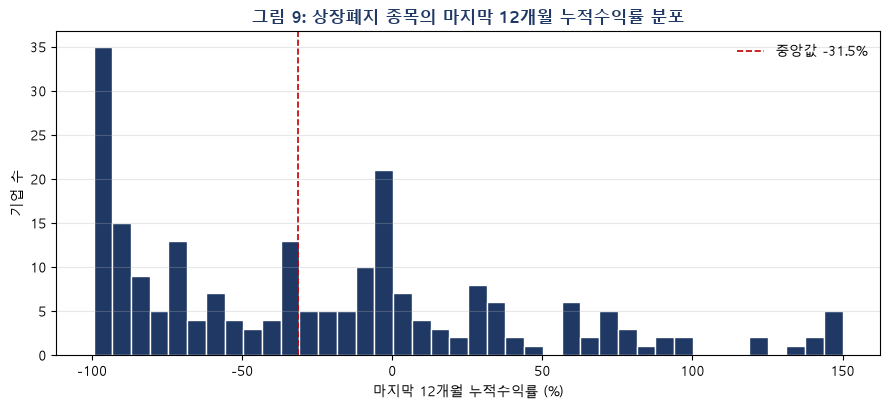

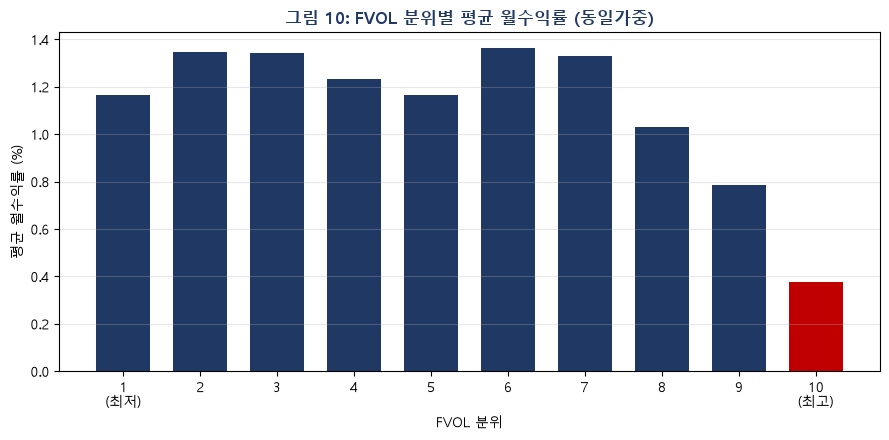

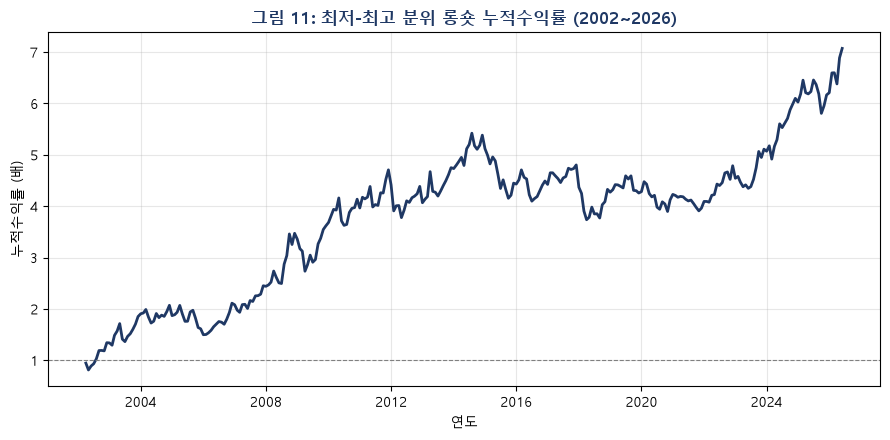

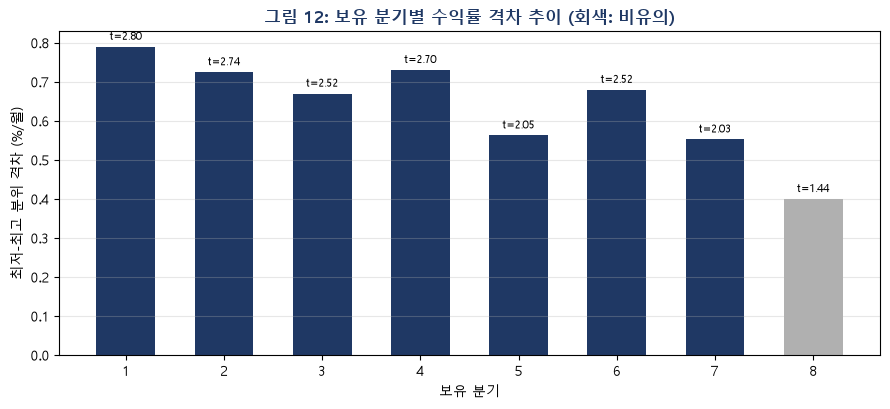

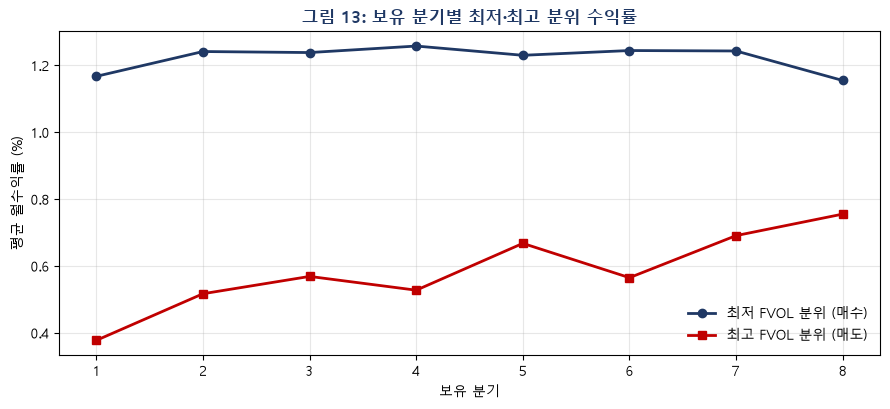

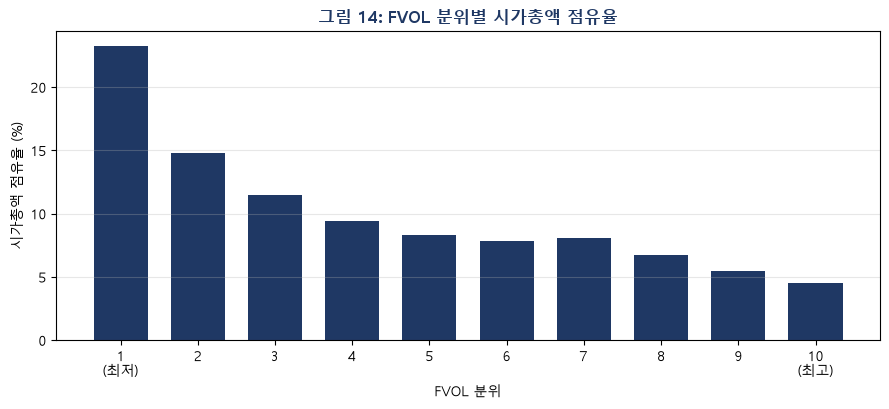

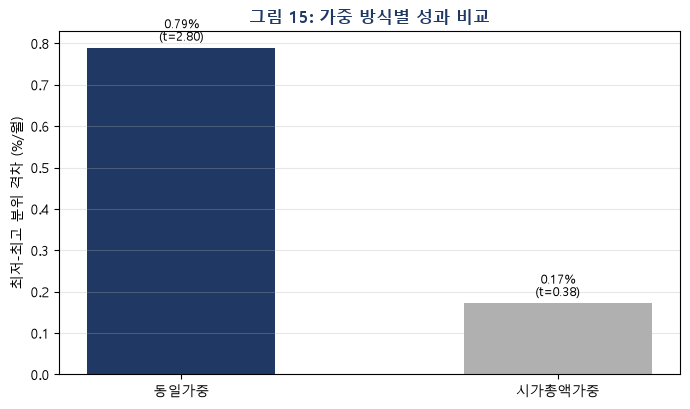

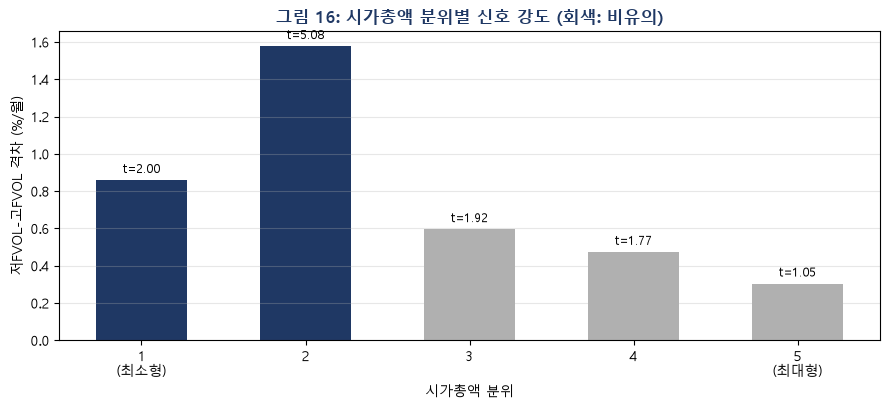

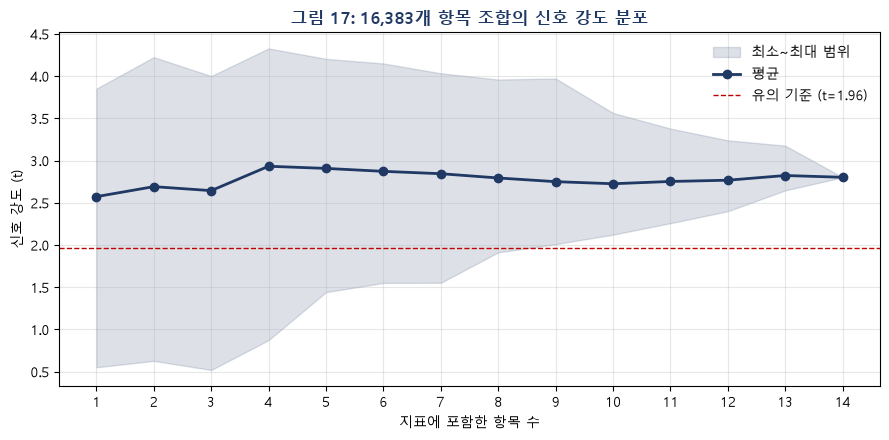

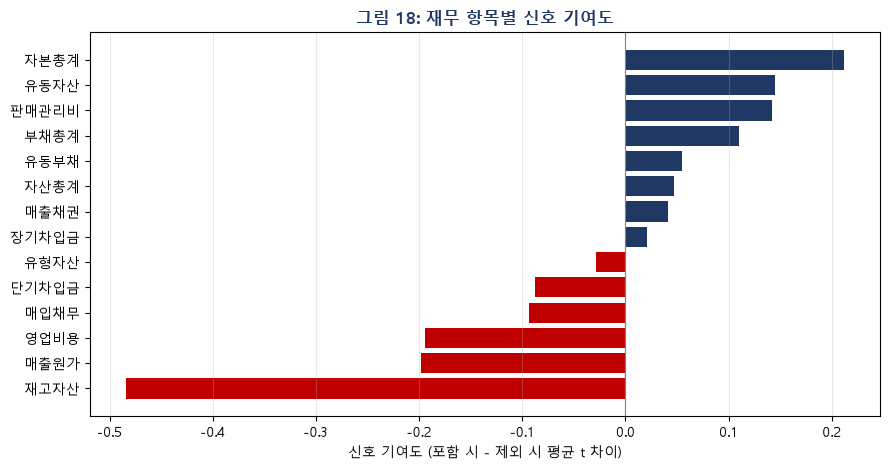

In [16]:
# 시각화

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
NAVY = '#1F3864'
RED = '#C00000'
GRAY = '#B0B0B0'

prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')
ret_m = px[['code', 'ym', 'ret']].dropna()

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1
form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price', 'mktcap']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price', 'mktcap']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

fin_last = financials[financials['atq'].notna()].groupby('code')['date'].max()
cutoff = financials['date'].max()
delisted = fin_last[fin_last < cutoff - pd.Timedelta(days=200)].index
pd_del = px[px['code'].isin(delisted) & px['ret'].notna()].sort_values(['code', 'date'])
cum12 = pd_del.groupby('code').tail(12).groupby('code')['ret'].apply(lambda s: (1 + s).prod() - 1) * 100
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(cum12.clip(-100, 150), bins=40, color=NAVY, edgecolor='white')
ax.axvline(cum12.median(), color=RED, linestyle='--', linewidth=1.2, label=f'중앙값 {cum12.median():.1f}%')
ax.set_xlabel('마지막 12개월 누적수익률 (%)'); ax.set_ylabel('기업 수')
ax.set_title('그림 9: 상장폐지 종목의 마지막 12개월 누적수익률 분포', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
m = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym'])
ew = m.groupby(['ym', 'decile'])['ret'].mean().reset_index(name='r')
wide = ew.pivot(index='ym', columns='decile', values='r')
dec_mean = wide[list(range(1, 11))].mean() * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [NAVY] * 9 + [RED]
ax.bar(range(1, 11), dec_mean.values, color=colors, width=0.7)
ax.set_xticks(range(1, 11)); ax.set_xticklabels(['1\n(최저)'] + [str(i) for i in range(2, 10)] + ['10\n(최고)'])
ax.set_xlabel('FVOL 분위'); ax.set_ylabel('평균 월수익률 (%)')
ax.set_title('그림 10: FVOL 분위별 평균 월수익률 (동일가중)', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

lh_m = (wide[1] - wide[10]).dropna()
cum = (1 + lh_m).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cum.index.to_timestamp(), cum.values, color=NAVY, linewidth=2)
ax.axhline(1, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('연도'); ax.set_ylabel('누적수익률 (배)')
ax.set_title('그림 11: 최저-최고 분위 롱숏 누적수익률 (2002~2026)', fontweight='bold', color=NAVY)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

holds = []
for k in range(1, 25):
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    h['qtr'] = (k - 1) // 3 + 1
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
m = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym', 'qtr'])
ewq = m.groupby(['qtr', 'ym', 'decile'])['ret'].mean().reset_index(name='r')
lh_q, t_q, lo_q, hi_q = [], [], [], []
for qtr in range(1, 9):
    w = ewq[ewq['qtr'] == qtr].pivot(index='ym', columns='decile', values='r')
    lh = (w[1] - w[10]).dropna()
    lh_q.append(lh.mean() * 100)
    t_q.append(lh.mean() / (lh.std(ddof=1) / np.sqrt(len(lh))))
    lo_q.append(w[1].mean() * 100)
    hi_q.append(w[10].mean() * 100)

fig, ax = plt.subplots(figsize=(9, 4.2))
cols4 = [NAVY if t >= 1.96 else GRAY for t in t_q]
ax.bar(range(1, 9), lh_q, color=cols4, width=0.6)
for x, (y, t) in enumerate(zip(lh_q, t_q), start=1):
    ax.annotate(f't={t:.2f}', (x, y), textcoords='offset points', xytext=(0, 5), ha='center', fontsize=8)
ax.set_xlabel('보유 분기'); ax.set_ylabel('최저-최고 분위 격차 (%/월)')
ax.set_title('그림 12: 보유 분기별 수익률 격차 추이 (회색: 비유의)', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(range(1, 9), lo_q, marker='o', color=NAVY, linewidth=2, label='최저 FVOL 분위 (매수)')
ax.plot(range(1, 9), hi_q, marker='s', color=RED, linewidth=2, label='최고 FVOL 분위 (매도)')
ax.set_xlabel('보유 분기'); ax.set_ylabel('평균 월수익률 (%)')
ax.set_title('그림 13: 보유 분기별 최저·최고 분위 수익률', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fm = f.dropna(subset=['mktcap']).copy()
qsum = fm.groupby('form_qtr')['mktcap'].transform('sum')
fm['share'] = fm['mktcap'] / qsum
share = fm.groupby(['form_qtr', 'decile'])['share'].sum().reset_index()
avg_share = share.groupby('decile')['share'].mean() * 100
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(range(1, 11), avg_share.values, color=NAVY, width=0.7)
ax.set_xticks(range(1, 11)); ax.set_xticklabels(['1\n(최저)'] + [str(i) for i in range(2, 10)] + ['10\n(최고)'])
ax.set_xlabel('FVOL 분위'); ax.set_ylabel('시가총액 점유율 (%)')
ax.set_title('그림 14: FVOL 분위별 시가총액 점유율', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

rp = px[['code', 'ym', 'ret', 'mktcap']].sort_values(['code', 'ym']).copy()
rp['w'] = rp.groupby('code')['mktcap'].shift(1)
holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
mv = rp.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
mv = mv.dropna(subset=['ret', 'w']).drop_duplicates(['code', 'form_ym', 'ym'])
vw = (mv.groupby(['ym', 'decile'])
      .apply(lambda g: (g['ret'] * g['w']).sum() / g['w'].sum(), include_groups=False)
      .reset_index(name='r'))
wv = vw.pivot(index='ym', columns='decile', values='r')
lh_vw = (wv[1] - wv[10]).dropna()
ew_val, ew_t = lh_m.mean() * 100, lh_m.mean() / (lh_m.std(ddof=1) / np.sqrt(len(lh_m)))
vw_val, vw_t = lh_vw.mean() * 100, lh_vw.mean() / (lh_vw.std(ddof=1) / np.sqrt(len(lh_vw)))
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar([0, 1], [ew_val, vw_val], color=[NAVY, GRAY], width=0.5)
for x, (y, t) in enumerate(zip([ew_val, vw_val], [ew_t, vw_t])):
    ax.annotate(f'{y:.2f}%\n(t={t:.2f})', (x, y), textcoords='offset points', xytext=(0, 5), ha='center', fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels(['동일가중', '시가총액가중'])
ax.set_ylabel('최저-최고 분위 격차 (%/월)')
ax.set_title('그림 15: 가중 방식별 성과 비교', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

fs = f.dropna(subset=['mktcap']).copy()
fs['size_q'] = fs.groupby('form_qtr')['mktcap'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')) + 1
fs['fq'] = fs.groupby(['form_qtr', 'size_q'])['FVOL'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')) + 1
fs = fs.dropna(subset=['fq'])
holds = []
for k in [1, 2, 3]:
    h = fs[['code', 'form_ym', 'size_q', 'fq']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)
ms = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
ms = ms.drop_duplicates(['code', 'form_ym', 'ym'])
cell = ms.groupby(['size_q', 'ym', 'fq'])['ret'].mean().reset_index(name='r')
sz_lh, sz_t = [], []
for sq in range(1, 6):
    w = cell[cell['size_q'] == sq].pivot(index='ym', columns='fq', values='r')
    lh = (w[1] - w[5]).dropna()
    sz_lh.append(lh.mean() * 100)
    sz_t.append(lh.mean() / (lh.std(ddof=1) / np.sqrt(len(lh))))
fig, ax = plt.subplots(figsize=(9, 4.2))
cols8 = [NAVY if t >= 1.96 else GRAY for t in sz_t]
ax.bar(range(1, 6), sz_lh, color=cols8, width=0.55)
for x, (y, t) in enumerate(zip(sz_lh, sz_t), start=1):
    ax.annotate(f't={t:.2f}', (x, y), textcoords='offset points', xytext=(0, 5), ha='center', fontsize=9)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(['1\n(최소형)', '2', '3', '4', '5\n(최대형)'])
ax.set_xlabel('시가총액 분위'); ax.set_ylabel('저FVOL-고FVOL 격차 (%/월)')
ax.set_title('그림 16: 시가총액 분위별 신호 강도 (회색: 비유의)', fontweight='bold', color=NAVY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

res = pd.read_parquet('combo_full_all.parquet')
gb = res.groupby('k')['t'].agg(['mean', 'min', 'max'])
fig, ax = plt.subplots(figsize=(9, 4.5))
ks = gb.index.values
ax.fill_between(ks, gb['min'], gb['max'], color=NAVY, alpha=0.15, label='최소~최대 범위')
ax.plot(ks, gb['mean'], marker='o', color=NAVY, linewidth=2, label='평균')
ax.axhline(1.96, color=RED, linestyle='--', linewidth=1, label='유의 기준 (t=1.96)')
ax.set_xticks(ks)
ax.set_xlabel('지표에 포함한 항목 수'); ax.set_ylabel('신호 강도 (t)')
ax.set_title('그림 17: 16,383개 항목 조합의 신호 강도 분포', fontweight='bold', color=NAVY)
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

inc = np.load('combo_inc_mask.npy')
tv = res['t'].to_numpy()
ok_t = ~np.isnan(tv)
contrib = {}
for j, c in enumerate(FVOL_COLS):
    contrib[c] = tv[inc[:, j] & ok_t].mean() - tv[~inc[:, j] & ok_t].mean()
contrib = pd.Series(contrib).sort_values()
KOR = {'actq': '유동자산', 'rectq': '매출채권', 'invtq': '재고자산', 'ppentq': '유형자산',
       'atq': '자산총계', 'lctq': '유동부채', 'dlcq': '단기차입금', 'apq': '매입채무',
       'dlttq': '장기차입금', 'ltq': '부채총계', 'seqq': '자본총계',
       'xoprq': '영업비용', 'cogsq': '매출원가', 'xsgaq': '판매관리비'}
labels = [KOR[c] for c in contrib.index]
colors10 = [RED if v < 0 else NAVY for v in contrib.values]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(range(len(contrib)), contrib.values, color=colors10)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_yticks(range(len(contrib))); ax.set_yticklabels(labels)
ax.set_xlabel('신호 기여도 (포함 시 - 제외 시 평균 t 차이)')
ax.set_title('그림 18: 재무 항목별 신호 기여도', fontweight='bold', color=NAVY)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
# 14

financials = pd.read_parquet('financials.parquet')
prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)

m = px[['code', 'ym', 'ret']].dropna().merge(
    hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym'])

ew = m.groupby(['ym', 'decile'])['ret'].mean().reset_index(name='r')
wide = ew.pivot(index='ym', columns='decile', values='r')
lh_m = (wide[1] - wide[10]).dropna()

yr = lh_m.copy()
yr.index = yr.index.year
lo_y = wide[1].dropna().copy(); lo_y.index = lo_y.index.year
hi_y = wide[10].dropna().copy(); hi_y.index = hi_y.index.year
lo_ann = lo_y.groupby(level=0).mean()
hi_ann = hi_y.groupby(level=0).mean()

print(f'{"연도":>5}{"격차%/월":>7}  승패{"양수월":>5}{"Low%":>7}{"High%":>7}')
for y, g in yr.groupby(level=0):
    win = ' 승' if g.mean() > 0 else ' 패'
    pos = (g > 0).mean()
    print(f'{y:>6}{g.mean()*100:>9.2f}{win:>4}{pos:>7.0%}{lo_ann[y]*100:>8.2f}{hi_ann[y]*100:>8.2f}')

ann = yr.groupby(level=0).mean()
print(f'\n승리 연도: {(ann > 0).sum()}/{len(ann)}  '
      f'최고 {ann.idxmax()} ({ann.max()*100:.2f}%/월)  '
      f'최악 {ann.idxmin()} ({ann.min()*100:.2f}%/월)')


   연도  격차%/월  승패  양수월   Low%  High%
  2002     3.74   승    67%   -2.29   -6.02
  2003     3.05   승    67%    2.05   -1.01
  2004     1.05   승    67%    1.46    0.41
  2005    -1.85   패    50%    5.81    7.66
  2006     2.36   승    75%    1.19   -1.17
  2007     1.34   승    58%    2.58    1.23
  2008     3.16   승    58%   -2.94   -6.09
  2009     0.53   승    58%    3.79    3.27
  2010     1.22   승    75%    1.87    0.65
  2011     1.18   승    58%    0.32   -0.86
  2012    -0.47   패    67%    1.91    2.39
  2013     0.79   승    67%    1.39    0.61
  2014     1.09   승    67%    1.88    0.78
  2015    -1.51   패    33%    2.07    3.58
  2016     0.12   승    58%   -0.13   -0.25
  2017     0.58   승    50%    0.70    0.11
  2018    -0.74   패    50%   -0.32    0.42
  2019    -0.10   패    33%   -0.07    0.03
  2020    -0.21   패    42%    1.98    2.19
  2021    -0.33   패    33%    1.59    1.92
  2022     1.62   승    67%   -0.70   -2.32
  2023     0.60   승    58%    1.06    0.46
  2024     1.52   

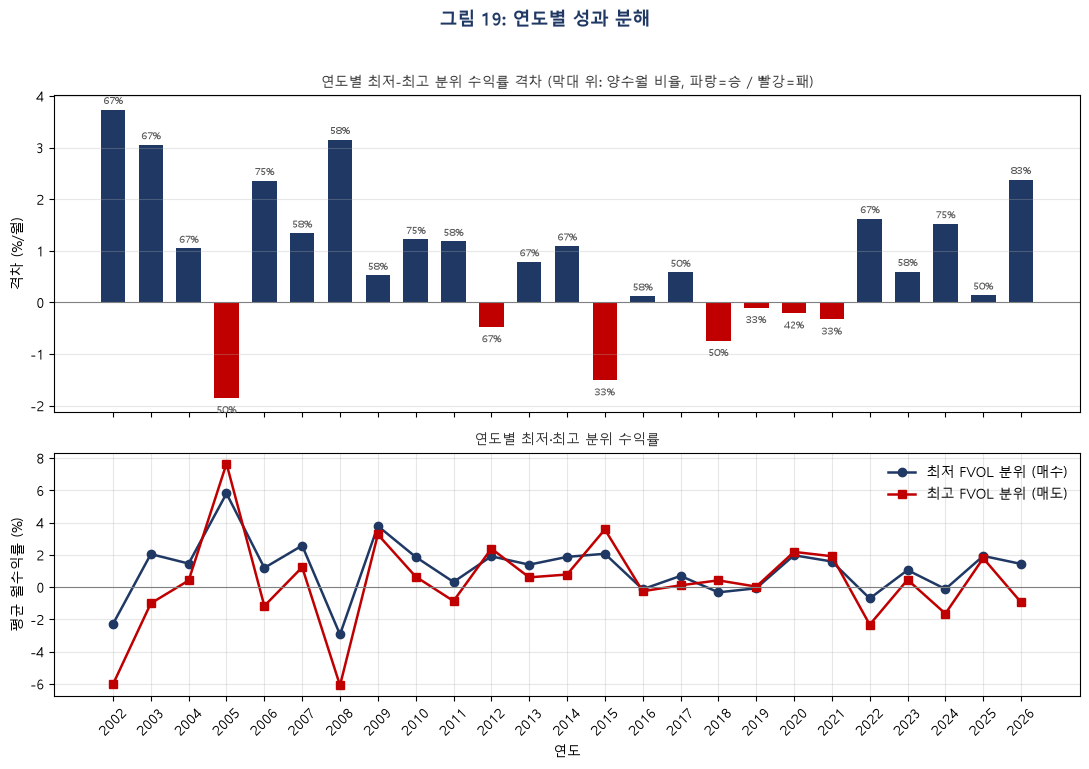

In [18]:
# 시각화

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
NAVY = '#1F3864'
RED = '#C00000'

financials = pd.read_parquet('financials.parquet')
prices = pd.read_parquet('prices.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].copy()
f['decile'] = np.ceil(f.groupby('form_qtr')['FVOL'].rank(pct=True) * 10).clip(1, 10).astype(int)
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'decile']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)

m = px[['code', 'ym', 'ret']].dropna().merge(
    hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym'])

ew = m.groupby(['ym', 'decile'])['ret'].mean().reset_index(name='r')
wide = ew.pivot(index='ym', columns='decile', values='r')
lh_m = (wide[1] - wide[10]).dropna()

yr = lh_m.copy()
yr.index = yr.index.year
ann = yr.groupby(level=0).mean() * 100
pos = yr.groupby(level=0).apply(lambda g: (g > 0).mean())
lo_y = wide[1].dropna().copy(); lo_y.index = lo_y.index.year
hi_y = wide[10].dropna().copy(); hi_y.index = hi_y.index.year
lo_ann = lo_y.groupby(level=0).mean() * 100
hi_ann = hi_y.groupby(level=0).mean() * 100
years = ann.index.values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.8), sharex=True,
                               gridspec_kw={'height_ratios': [1.3, 1]})
fig.suptitle('그림 19: 연도별 성과 분해', fontweight='bold', color=NAVY, fontsize=13)

# 상단: 연도별 격차 (승=NAVY, 패=RED) + 양수월 주석
colors = [NAVY if v > 0 else RED for v in ann.values]
ax1.bar(years, ann.values, color=colors, width=0.65)
ax1.axhline(0, color='grey', linewidth=0.8)
for x, v, p in zip(years, ann.values, pos.values):
    ax1.annotate(f'{p:.0%}', (x, v), textcoords='offset points',
                 xytext=(0, 4 if v > 0 else -11), ha='center', fontsize=7, color='#555555')
ax1.set_ylabel('격차 (%/월)')
ax1.set_title('연도별 최저-최고 분위 수익률 격차 (막대 위: 양수월 비율, 파랑=승 / 빨강=패)',
              fontsize=10, color='#333333')
ax1.grid(axis='y', alpha=0.3)

# 하단: Low / High 실제 수익률
ax2.plot(years, lo_ann.values, marker='o', color=NAVY, linewidth=1.8, label='최저 FVOL 분위 (매수)')
ax2.plot(years, hi_ann.values, marker='s', color=RED, linewidth=1.8, label='최고 FVOL 분위 (매도)')
ax2.axhline(0, color='grey', linewidth=0.8)
ax2.set_ylabel('평균 월수익률 (%)')
ax2.set_xlabel('연도')
ax2.set_title('연도별 최저·최고 분위 수익률', fontsize=10, color='#333333')
ax2.legend(frameon=False)
ax2.grid(alpha=0.3)
ax2.set_xticks(years)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

In [19]:
# 15

raw = pd.read_excel(XLSX, sheet_name='33_industry', header=None)

codes = raw.iloc[7, 1:].astype(str).tolist()
body = raw.iloc[14:, :].copy()
dates = pd.PeriodIndex(body.iloc[:, 0].astype(str), freq='M')

ind_wide = body.iloc[:, 1:]
ind_wide.columns = codes
ind_wide.index = dates.year

ind_wide = ind_wide.rename_axis(index='year', columns='code')
ind_long = ind_wide.stack().rename('industry').reset_index()
ind_long = ind_long.dropna(subset=['industry'])
ind_long['industry'] = ind_long['industry'].astype(str).str.strip()
ind_long = ind_long[ind_long['industry'].ne('') & ind_long['industry'].ne('nan')]
ind_long = ind_long[~ind_long['code'].isin(EXCLUDE_FIN)]

ind_long.to_parquet('industry.parquet')
print(f'industry.parquet 저장: {len(ind_long)}행, 종목 {ind_long["code"].nunique()}개, '
      f'연도 {ind_long["year"].min()}~{ind_long["year"].max()}')
print(f'대분류 종류({ind_long["industry"].nunique()}개): {sorted(ind_long["industry"].unique())}')

financials = pd.read_parquet('financials.parquet')
fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

valid = fv[fv['FVOL'].notna()][['code', 'date']].copy()
valid['apply_year'] = valid['date'].dt.year
valid['ind_year'] = valid['apply_year'] - 1

merged = valid.merge(ind_long.rename(columns={'year': 'ind_year'}),
                     on=['code', 'ind_year'], how='left')
miss = merged['industry'].isna()
print(f'\nFVOL 유효 종목-분기 {len(merged)}개 중 분류 결측 {miss.sum()}개 ({miss.mean():.2%})')
if miss.any():
    mc = merged[miss]
    print(f'결측 종목 수: {mc["code"].nunique()}개, 결측 집중 연도 상위 5:')
    print(mc['apply_year'].value_counts().head(5).to_string())

print('\n연도별 대분류 분포 (종목 수, FVOL 유효 기준, 5년 간격):')
tab = merged.dropna(subset=['industry'])
pv = tab[tab['apply_year'].isin([2005, 2010, 2015, 2020, 2025])].pivot_table(
    index='industry', columns='apply_year', values='code', aggfunc='nunique', fill_value=0)
print(pv.to_string())

industry.parquet 저장: 18387행, 종목 995개, 연도 1999~2025
대분류 종류(9개): ['IT', '건강관리', '경기관련소비재', '산업재', '소재', '에너지', '유틸리티', '커뮤니케이션서비스', '필수소비재']

FVOL 유효 종목-분기 66765개 중 분류 결측 1086개 (1.63%)
결측 종목 수: 137개, 결측 집중 연도 상위 5:
apply_year
2006    97
2005    88
2007    87
2004    81
2008    81

연도별 대분류 분포 (종목 수, FVOL 유효 기준, 5년 간격):
apply_year  2005  2010  2015  2020  2025
industry                                
IT            76    78    66    66    75
건강관리          42    44    48    52    61
경기관련소비재      141   150   160   169   175
산업재          137   144   163   173   179
소재           141   153   153   149   155
에너지            7    11    13    13    17
유틸리티          12    14    17    17    16
커뮤니케이션서비스      5     5     3    27    26
필수소비재         50    51    56    58    55


In [20]:
# 16

financials = pd.read_parquet('financials.parquet')
ind_long = pd.read_parquet('industry.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

v = fv[fv['FVOL'].notna()][['code', 'date', 'FVOL']].copy()
v['ind_year'] = v['date'].dt.year - 1
v = v.merge(ind_long.rename(columns={'year': 'ind_year'}),
            on=['code', 'ind_year'], how='inner')

q = v.groupby(['date', 'industry'])['FVOL'].agg(['mean', 'count']).reset_index()
lvl = q.groupby('industry').apply(
    lambda g: pd.Series({'평균FVOL': g['mean'].mean(),
                         '분기당종목': g['count'].mean()}), include_groups=False)
lvl = lvl.sort_values('평균FVOL', ascending=False)
print('=== 1. 업종별 평균 FVOL rank (0~1, 높을수록 고변동) ===')
print(lvl.round(3).to_string())

grand = v['FVOL'].mean()
between = v.groupby('industry')['FVOL'].agg(['mean', 'count'])
ss_between = (between['count'] * (between['mean'] - grand) ** 2).sum()
ss_total = ((v['FVOL'] - grand) ** 2).sum()
print(f'\n=== 2. FVOL 분산 중 업종 간 차이가 설명하는 비율 ===')
print(f'업종 간 분산 비율: {ss_between / ss_total:.1%}  (나머지 {1 - ss_between/ss_total:.1%}는 업종 내 기업 간 차이)')

v['decile'] = v.groupby('date')['FVOL'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')) + 1
base = v.groupby('industry').size() / len(v)
print('\n=== 3. 업종 비중: 전체 vs d1 vs d10 (%) ===')
out = pd.DataFrame({'전체': base * 100})
for dc, nm in [(1, 'd1(저변동)'), (10, 'd10(고변동)')]:
    d = v[v['decile'] == dc]
    out[nm] = d.groupby('industry').size() / len(d) * 100
out['d10−전체'] = out['d10(고변동)'] - out['전체']
print(out.round(1).sort_values('d10−전체', ascending=False).to_string())

=== 1. 업종별 평균 FVOL rank (0~1, 높을수록 고변동) ===
           평균FVOL    분기당종목
industry                  
IT          0.593   71.245
산업재         0.521  156.510
에너지         0.515   10.980
건강관리        0.512   48.102
경기관련소비재     0.494  158.459
소재          0.478  146.806
커뮤니케이션서비스   0.472    9.776
필수소비재       0.430   53.194
유틸리티        0.334   15.122

=== 2. FVOL 분산 중 업종 간 차이가 설명하는 비율 ===
업종 간 분산 비율: 5.3%  (나머지 94.7%는 업종 내 기업 간 차이)

=== 3. 업종 비중: 전체 vs d1 vs d10 (%) ===
             전체  d1(저변동)  d10(고변동)  d10−전체
industry                                  
IT         10.6      4.4      20.5     9.8
산업재        23.4     20.3      25.7     2.3
에너지         1.6      2.4       3.3     1.7
건강관리        7.2      5.1       8.7     1.5
경기관련소비재    23.6     25.4      24.2     0.6
커뮤니케이션서비스   1.5      0.5       2.0     0.5
유틸리티        2.3      7.5       0.3    -2.0
필수소비재       7.9     15.1       4.3    -3.6
소재         21.9     19.2      11.1   -10.8


In [21]:
# 17

financials = pd.read_parquet('financials.parquet')
prices = pd.read_parquet('prices.parquet')
ind_long = pd.read_parquet('industry.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

sig = fv[['code', 'date', 'FVOL']].dropna().copy()
sig['ind_year'] = sig['date'].dt.year - 1
sig = sig.merge(ind_long.rename(columns={'year': 'ind_year'}),
                on=['code', 'ind_year'], how='inner')
sig['form_qtr'] = pd.PeriodIndex(sig['date'], freq='Q') + 1

px = prices.copy()
px['ret'] = px['ret'] / 100.0
px['ym'] = pd.PeriodIndex(px['date'], freq='M')

form_px = px[px['ym'].dt.month.isin([3, 6, 9, 12])][['code', 'ym', 'price']].copy()
form_px['form_qtr'] = form_px['ym'].dt.asfreq('Q')

f = sig.merge(form_px[['code', 'form_qtr', 'price']], on=['code', 'form_qtr'], how='inner')
f = f[f['price'] >= 1000].copy()
f['q5'] = f.groupby(['form_qtr', 'industry'])['FVOL'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')) + 1
f = f.dropna(subset=['q5'])
f['form_ym'] = f['form_qtr'].dt.asfreq('M', how='end')

ret_m = px[['code', 'ym', 'ret']].dropna()
holds = []
for k in [1, 2, 3]:
    h = f[['code', 'form_ym', 'industry', 'q5']].copy()
    h['hold_ym'] = h['form_ym'] + k
    holds.append(h)
hold = pd.concat(holds, ignore_index=True)

m = ret_m.merge(hold, left_on=['code', 'ym'], right_on=['code', 'hold_ym'], how='inner')
m = m.drop_duplicates(['code', 'form_ym', 'ym'])
cell = m.groupby(['industry', 'ym', 'q5'])['ret'].mean().reset_index(name='r')

nq = f.groupby(['form_qtr', 'industry']).size().groupby('industry').mean()

print(f'{"industry":12}{"L-H%":>7}{"t":>7}{"Low%":>7}{"High%":>7}{"월수":>6}{"종목/분기":>9}')
for indus in sorted(f['industry'].unique()):
    w = cell[cell['industry'] == indus].pivot(index='ym', columns='q5', values='r')
    if 1 not in w.columns or 5 not in w.columns:
        continue
    lh = (w[1] - w[5]).dropna()
    if len(lh) < 24:
        continue
    t = lh.mean() / (lh.std(ddof=1) / np.sqrt(len(lh)))
    print(f'{indus:12}{lh.mean()*100:>7.2f}{t:>7.2f}{w[1].mean()*100:>7.2f}{w[5].mean()*100:>7.2f}{len(lh):>6d}{nq[indus]:>9.0f}')

industry       L-H%      t   Low%  High%    월수    종목/분기
IT             1.14   2.22   1.64   0.49   291       66
건강관리           0.21   0.49   1.13   0.92   291       47
경기관련소비재        0.73   2.40   1.01   0.28   291      147
산업재            0.58   1.76   1.37   0.79   291      148
소재             0.47   1.83   1.31   0.84   291      136
에너지            1.16   1.71   1.39   0.23   291       10
유틸리티          -0.08  -0.20   1.23   1.31   291       15
커뮤니케이션서비스      0.52   0.92   0.34  -0.11   288       10
필수소비재          0.15   0.33   1.14   0.99   291       51


In [22]:
# 진단

financials = pd.read_parquet('financials.parquet')

fv, ind = compute_fvol(financials, deflator='saleq')
fv, col = finalize_fvol(fv, ind, suffix='')

d = fv.sort_values(['code', 'date']).copy()
d['qtr'] = pd.PeriodIndex(d['date'], freq='Q')
d['loss'] = (d['ibq'] < 0).astype(float)
d['neg_eq'] = (d['seqq'] < 0).astype(float)
d['lev'] = (d['ltq'] / d['atq']).replace([np.inf, -np.inf], np.nan)
d['fvol_rank'] = d.groupby('date')['FVOL'].rank(pct=True)

fin_last = financials[financials['atq'].notna()].groupby('code')['date'].max()
cutoff = financials['date'].max()
delisted = fin_last[fin_last < cutoff - pd.Timedelta(days=200)].index
last_q = pd.PeriodIndex(fin_last, freq='Q')
last_map = dict(zip(fin_last.index, last_q))

d['last_q'] = d['code'].map(last_map)
d['rel'] = (d['last_q'] - d['qtr']).map(lambda x: x.n if pd.notna(x) else np.nan)
dd = d[d['code'].isin(delisted)]

print('=== 1. 폐지 전 궤적 (폐지 종목, rel=마지막 재무분기까지 남은 분기) ===')
print(f'{"rel":>5}{"FVOL rank":>11}{"적자비율":>9}{"자본잠식":>9}{"부채비율":>9}{"n":>7}')
for r in [12, 8, 6, 4, 2, 1, 0]:
    g = dd[dd['rel'] == r]
    print(f'-{r:>4}{g["fvol_rank"].mean():>11.3f}{g["loss"].mean():>9.1%}'
          f'{g["neg_eq"].mean():>9.1%}{g["lev"].mean():>9.2f}{g["fvol_rank"].notna().sum():>7}')
g = d[~d['code'].isin(delisted)]
print(f'{"생존":>5}{g["fvol_rank"].mean():>11.3f}{g["loss"].mean():>9.1%}'
      f'{g["neg_eq"].mean():>9.1%}{g["lev"].mean():>9.2f}')

v = d[d['FVOL'].notna()].copy()
v['dec'] = np.ceil(v['fvol_rank'] * 10).clip(1, 10).astype(int)
for h in [4, 8]:
    v[f'del{h}'] = ((v['rel'] > 0) & (v['rel'] <= h) & v['code'].isin(delisted)).astype(float)

print('\n=== 2. FVOL decile별 폐지 확률 ===')
print(f'{"decile":>7}{"4분기내%":>9}{"8분기내%":>9}')
for dc in range(1, 11):
    g = v[v['dec'] == dc]
    print(f'{dc:>7}{g["del4"].mean():>9.2%}{g["del8"].mean():>9.2%}')
print(f'{"전체":>7}{v["del4"].mean():>9.2%}{v["del8"].mean():>9.2%}')

print('\n=== 3. 조기 경보 검정: 아직 적자가 아닌 기업 한정 ===')
nl = v[v['ibq'] >= 0]
print(f'표본 {len(nl)} (전체의 {len(nl)/len(v):.0%})')
print(f'{"decile":>7}{"8분기내 폐지%":>13}')
for dc in [1, 5, 8, 9, 10]:
    g = nl[nl['dec'] == dc]
    print(f'{dc:>7}{g["del8"].mean():>13.2%}')
print(f'{"전체":>7}{nl["del8"].mean():>13.2%}')

print('\n=== 4. 항목별 선행 궤적 (폐지 종목 평균 rank) ===')
rcols = [f'rank_{c}' for c in FVOL_COLS]
print(f'{"item":>8}{"rel-12":>8}{"rel-8":>8}{"rel-4":>8}{"rel-1":>8}')
for c in FVOL_COLS:
    row = f'{c:>8}'
    for r in [12, 8, 4, 1]:
        row += f'{dd.loc[dd["rel"] == r, f"rank_{c}"].mean():>8.3f}'
    print(row)

=== 1. 폐지 전 궤적 (폐지 종목, rel=마지막 재무분기까지 남은 분기) ===
  rel  FVOL rank     적자비율     자본잠식     부채비율      n
-  12      0.652    52.0%     5.1%     0.58    144
-   8      0.670    52.4%     6.5%     0.62    157
-   6      0.698    57.1%    10.7%     0.67    170
-   4      0.712    58.5%    11.6%     0.71    177
-   2      0.720    63.3%    19.7%     0.88    180
-   1      0.728    59.9%    20.7%     1.00    181
-   0      0.736    65.3%    30.2%     1.09    194
   생존      0.485    18.4%     0.4%     0.47

=== 2. FVOL decile별 폐지 확률 ===
 decile    4분기내%    8분기내%
      1    0.57%    1.10%
      2    0.51%    1.06%
      3    0.43%    0.81%
      4    0.33%    0.60%
      5    0.54%    1.20%
      6    0.59%    1.37%
      7    0.85%    1.83%
      8    0.78%    1.75%
      9    1.89%    3.40%
     10    4.21%    7.47%
     전체    1.07%    2.06%

=== 3. 조기 경보 검정: 아직 적자가 아닌 기업 한정 ===
표본 47260 (전체의 71%)
 decile     8분기내 폐지%
      1        0.95%
      5        1.16%
      8        1.22%
      9        

In [23]:
# 진단

raw = pd.read_excel(XLSX, sheet_name='34_delisted', header=None)

body = raw.iloc[13:, :].reset_index(drop=True)
codes = body.iloc[:, 0].astype(str)
mask = codes.str.startswith('A')
off = pd.DataFrame({
    'code': codes[mask].values,
    'name': body.loc[mask.values, 1].astype(str).values,
    'del_date': pd.to_datetime(body.loc[mask.values, 3].astype('Int64').astype(str), format='%Y%m%d', errors='coerce').values,
    'reason': body.loc[mask.values, 4].astype(str).values,
})
print(f'공식 폐지 목록: {len(off)}개, 폐지일 결측 {off["del_date"].isna().sum()}개')
print(f'폐지일 범위: {off["del_date"].min()} ~ {off["del_date"].max()}')

financials = pd.read_parquet('financials.parquet')
univ = set(financials['code'].unique())
off_in = off[off['code'].isin(univ)]
print(f'\n우리 유니버스(1107) 내 공식 폐지: {len(off_in)}개 (유니버스 밖 {len(off) - len(off_in)}개)')

fin_last = financials[financials['atq'].notna()].groupby('code')['date'].max()
cutoff = financials['date'].max()
ours = set(fin_last[fin_last < cutoff - pd.Timedelta(days=200)].index)
official = set(off_in['code'])

both = ours & official
only_ours = ours - official
only_off = official - ours
print(f'\n교집합 {len(both)}  우리만 {len(only_ours)}  공식만 {len(only_off)}')

if only_ours:
    print(f'\n우리만 폐지로 판정한 종목 ({len(only_ours)}개):')
    print(sorted(only_ours))

if only_off:
    oo = off_in[off_in['code'].isin(only_off)].copy()
    oo = oo.merge(fin_last.rename('fin_last'), left_on='code', right_index=True, how='left')
    print(f'\n공식 폐지인데 우리가 놓친 종목 ({len(only_off)}개), 폐지 연도 분포:')
    print(oo['del_date'].dt.year.value_counts().sort_index().to_string())
    print('\n재무 종료 시점 분포 (놓친 이유 판별):')
    print(f'재무가 최근까지 존재(200일 기준 미충족): {(oo["fin_last"] >= cutoff - pd.Timedelta(days=200)).sum()}개')
    print(f'재무 자체가 없음: {oo["fin_last"].isna().sum()}개')

print('\n폐지 사유 분포 (유니버스 내 전체, 키워드 분류):')
r = off_in['reason'].fillna('')
cat = pd.Series(np.select(
    [r.str.contains('합병|해산'), r.str.contains('자본전액잠식|자본잠식'),
     r.str.contains('감사의견|의견거절'), r.str.contains('회사정리|정리절차|회생'),
     r.str.contains('신청|자진')],
    ['합병·해산', '자본잠식', '감사의견', '정리절차', '자진·신청'], default='기타'))
print(cat.value_counts().to_string())

공식 폐지 목록: 355개, 폐지일 결측 0개
폐지일 범위: 1991-06-13 00:00:00 ~ 2026-06-30 00:00:00

우리 유니버스(1107) 내 공식 폐지: 355개 (유니버스 밖 0개)

교집합 222  우리만 0  공식만 133

공식 폐지인데 우리가 놓친 종목 (133개), 폐지 연도 분포:
del_date
1991     4
1992     2
1993     3
1994    24
1995     6
1996    12
1997     7
1998    16
1999    35
2000    11
2016     1
2025     2
2026    10

재무 종료 시점 분포 (놓친 이유 판별):
재무가 최근까지 존재(200일 기준 미충족): 13개
재무 자체가 없음: 120개

폐지 사유 분포 (유니버스 내 전체, 키워드 분류):
합병·해산    114
기타        87
감사의견      71
정리절차      30
자본잠식      29
자진·신청     24
